# Google Stock Forecasting — TensorFlow RNN/LSTM

This notebook evaluates recurrent neural networks for next-day GOOG forecasting, including direct price models, return-based models, and an enhanced setup with market context from QQQ, SPY, and VIX.

> **Repository note:** saved outputs from the original Kaggle run are preserved. The notebook contains Kaggle input paths and also downloads current market data with `yfinance`, so a fresh rerun can produce different values from the saved outputs.


## Import Libraries & Setup

In [1]:
import os
import random
import warnings
from datetime import datetime
import yfinance as yf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")

device = "GPU" if gpus else "CPU"

print("Device:", device)

Device: CPU


2026-09-11 12:50:34.953238: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Load the Base Dataset

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The original GOOG CSV is loaded from the Kaggle input dataset and sorted by date.</li>
<li style="margin:4px 0;">The initial file is kept as a reproducible starting point before the live market-data update.</li>
</ul>
</div>

In [3]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/kianazesmaeili/google-dataset-stock-forecast/Google.csv


In [4]:
df = pd.read_csv(
    '/kaggle/input/datasets/kianazesmaeili/google-dataset-stock-forecast/Google.csv'
)

df.head()

,Unnamed: 0,open,high,low,close,adjclose,volume,ticker
0,2016-01-04,37.150002,37.202999,36.562901,37.091999,37.091999,65456000,GOOG
1,2016-01-05,37.322498,37.599998,36.931999,37.129002,37.129002,39014000,GOOG
2,2016-01-06,36.500000,37.359001,36.445999,37.181000,37.181000,38940000,GOOG
3,2016-01-07,36.515499,36.924999,35.952999,36.319500,36.319500,59274000,GOOG
4,2016-01-08,36.572498,36.661499,35.650002,35.723499,35.723499,49018000,GOOG


In [5]:
df = df.rename(columns={
    'Unnamed: 0': 'Date',
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'close': 'Close',
    'volume': 'Volume'
})

df['Date'] = pd.to_datetime(df['Date'])

df = df[
    ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
].copy()

df = df.sort_values('Date').reset_index(drop=True)

df.head()

,Date,Open,High,Low,Close,Volume
0,2016-01-04,37.150002,37.202999,36.562901,37.091999,65456000
1,2016-01-05,37.322498,37.599998,36.931999,37.129002,39014000
2,2016-01-06,36.500000,37.359001,36.445999,37.181000,38940000
3,2016-01-07,36.515499,36.924999,35.952999,36.319500,59274000
4,2016-01-08,36.572498,36.661499,35.650002,35.723499,49018000


In [6]:
print("Dataset shape:", df.shape)
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())

df.info()

Dataset shape: (2113, 6)
Start date: 2016-01-04 00:00:00
End date: 2024-05-24 00:00:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2113 entries, 0 to 2112
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2113 non-null   datetime64[ns]
 1   Open    2113 non-null   float64       
 2   High    2113 non-null   float64       
 3   Low     2113 non-null   float64       
 4   Close   2113 non-null   float64       
 5   Volume  2113 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 99.2 KB


## Update GOOG Market Data

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Recent GOOG daily market data is downloaded with Yahoo Finance.</li>
<li style="margin:4px 0;">The new observations are combined with the original dataset and duplicate dates are removed.</li>
</ul>
</div>

In [7]:
today = datetime.today().strftime('%Y-%m-%d')

goog_new = yf.download(
    'GOOG',
    start='2016-01-01',
    end=today,
    auto_adjust=False,
    progress=False
)

goog_new.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,,
2016-01-04,36.743973,37.091999,37.202999,36.562901,37.150002,65456000
2016-01-05,36.780628,37.129002,37.599998,36.931999,37.322498,39014000
2016-01-06,36.832146,37.181000,37.359001,36.445999,36.500000,38940000
2016-01-07,35.978722,36.319500,36.924999,35.952999,36.515499,59274000
2016-01-08,35.388309,35.723499,36.661499,35.650002,36.572498,49018000


In [8]:
if isinstance(goog_new.columns, pd.MultiIndex):
    goog_new.columns = goog_new.columns.get_level_values(0)

goog_new = goog_new.reset_index()

goog_new = goog_new[
    ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
].copy()

goog_new['Date'] = pd.to_datetime(goog_new['Date'])

goog_new.head()

Price,Date,Open,High,Low,Close,Volume
0,2016-01-04,37.150002,37.202999,36.562901,37.091999,65456000
1,2016-01-05,37.322498,37.599998,36.931999,37.129002,39014000
2,2016-01-06,36.500000,37.359001,36.445999,37.181000,38940000
3,2016-01-07,36.515499,36.924999,35.952999,36.319500,59274000
4,2016-01-08,36.572498,36.661499,35.650002,35.723499,49018000


In [9]:
df = pd.concat(
    [df, goog_new],
    ignore_index=True
)

df = (
    df
    .drop_duplicates(subset='Date', keep='last')
    .sort_values('Date')
    .reset_index(drop=True)
)

print("Updated dataset shape:", df.shape)
print("Start date:", df['Date'].min())
print("End date:", df['Date'].max())

Updated dataset shape: (2687, 6)
Start date: 2016-01-04 00:00:00
End date: 2026-09-10 00:00:00


In [10]:
df.tail()

,Date,Open,High,Low,Close,Volume
2682,2026-09-03,336.510010,340.850006,336.309998,339.079987,12858300
2683,2026-09-04,339.179993,340.179993,333.750000,335.309998,12700500
2684,2026-09-08,331.989990,336.480011,330.390015,335.380005,14150300
2685,2026-09-09,329.119995,329.339996,325.630005,328.380005,19326900
2686,2026-09-10,326.079987,330.890015,325.651001,330.390015,16392600


## Data Quality Checks

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Missing values and duplicated dates are checked before modeling.</li>
<li style="margin:4px 0;">Basic OHLC relationships, volume values, and chronological order are also verified.</li>
</ul>
</div>

In [11]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate dates:", df['Date'].duplicated().sum())

Missing values:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Duplicate rows: 0
Duplicate dates: 0


In [12]:
invalid_ohlc = df[
    (df['High'] < df[['Open', 'Close', 'Low']].max(axis=1)) |
    (df['Low'] > df[['Open', 'Close', 'High']].min(axis=1))
]

print("Invalid OHLC rows:", len(invalid_ohlc))

Invalid OHLC rows: 0


In [13]:
print("Negative volume rows:", (df['Volume'] < 0).sum())
print("Chronological order:", df['Date'].is_monotonic_increasing)

Negative volume rows: 0
Chronological order: True


In [14]:
df.describe()

,Date,Open,High,Low,Close,Volume
count,2687,2687.000000,2687.000000,2687.000000,2687.000000,2.687000e+03
mean,2021-05-05 05:49:24.942314752,116.143687,117.478462,114.914975,116.242374,2.846417e+07
min,2016-01-04 00:00:00,33.392502,33.615002,33.153000,33.412998,6.138200e+06
25%,2018-09-02 00:00:00,55.151501,55.684898,54.574999,55.127501,1.964940e+07
50%,2021-05-05 00:00:00,95.949997,97.547997,94.570000,96.029999,2.522320e+07
75%,2024-01-04 12:00:00,145.547256,146.915504,144.530502,145.680496,3.290400e+07
max,2026-09-10 00:00:00,397.059998,404.470001,393.670013,399.040009,1.269620e+08
std,NaN,80.779753,81.826365,79.804280,80.885196,1.374411e+07


## Exploratory Data Analysis

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Closing-price and trading-volume trends are visualized over time.</li>
<li style="margin:4px 0;">Daily returns are examined to better understand short-term market variability.</li>
</ul>
</div>

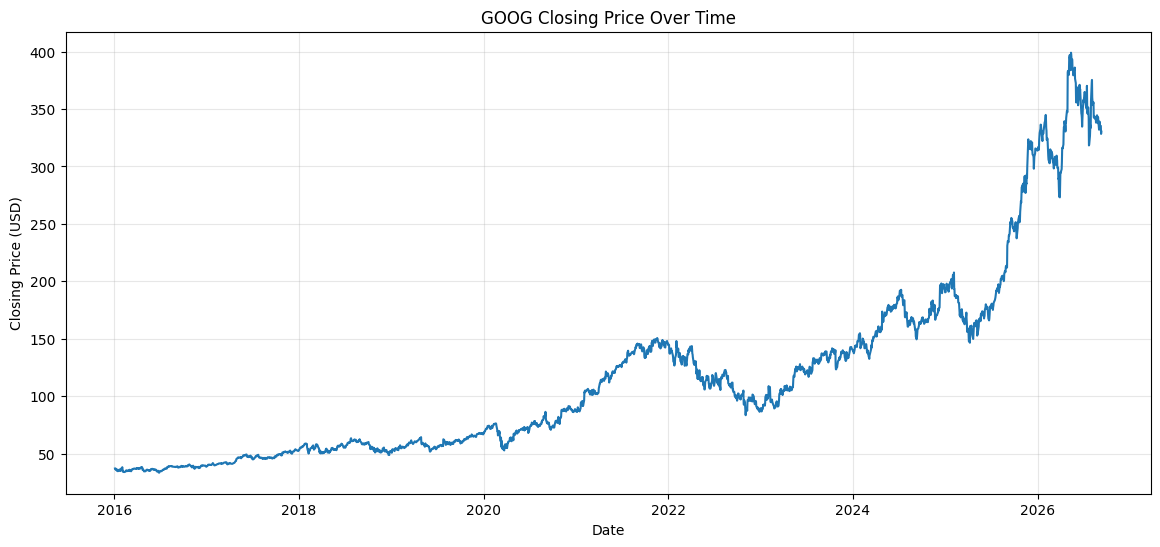

In [15]:
plt.figure(figsize=(14, 6))

plt.plot(
    df['Date'],
    df['Close']
)

plt.title('GOOG Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.grid(alpha=0.3)

plt.show()

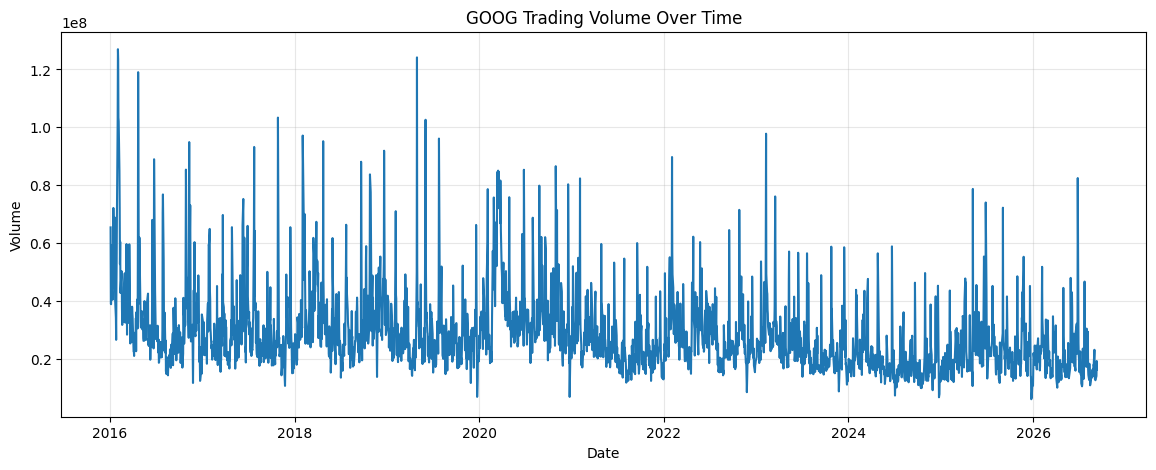

In [16]:
plt.figure(figsize=(14, 5))

plt.plot(
    df['Date'],
    df['Volume']
)

plt.title('GOOG Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(alpha=0.3)

plt.show()

In [17]:
df['Daily_Return'] = df['Close'].pct_change()

df[['Date', 'Close', 'Daily_Return']].head()

,Date,Close,Daily_Return
0,2016-01-04,37.091999,NaN
1,2016-01-05,37.129002,0.000998
2,2016-01-06,37.181000,0.001400
3,2016-01-07,36.319500,-0.023170
4,2016-01-08,35.723499,-0.016410


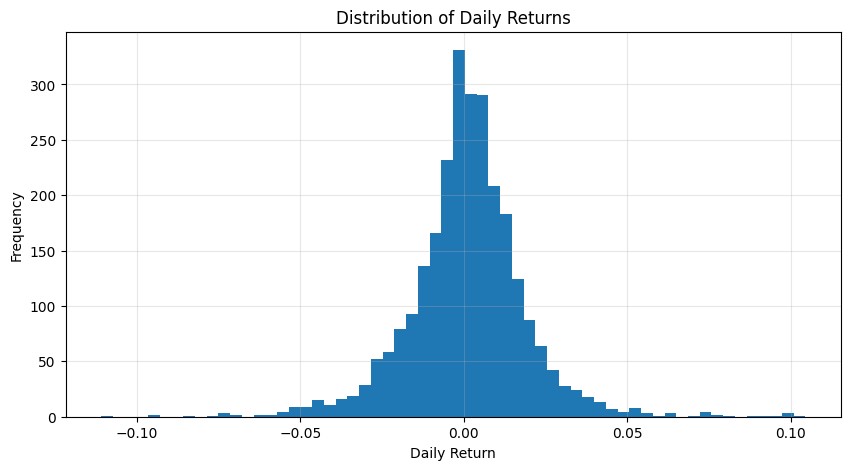

In [18]:
plt.figure(figsize=(10, 5))

plt.hist(
    df['Daily_Return'].dropna(),
    bins=60
)

plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)

plt.show()

In [19]:
df['Daily_Return'].describe()

count    2686.000000
mean        0.000981
std         0.018261
min        -0.111008
25%        -0.007504
50%         0.001198
75%         0.010220
max         0.104485
Name: Daily_Return, dtype: float64

## Correlation Analysis

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Correlations between the main numerical variables are examined.</li>
<li style="margin:4px 0;">This provides an initial view of how strongly the price-related features move together.</li>
</ul>
</div>

In [20]:
correlation_columns = [
    'Open',
    'High',
    'Low',
    'Close',
    'Volume',
    'Daily_Return'
]

correlation_matrix = df[
    correlation_columns
].corr()

correlation_matrix.round(3)

,Open,High,Low,Close,Volume,Daily_Return
Open,1.000,1.000,1.000,1.000,-0.327,0.009
High,1.000,1.000,1.000,1.000,-0.324,0.017
Low,1.000,1.000,1.000,1.000,-0.332,0.017
Close,1.000,1.000,1.000,1.000,-0.329,0.025
Volume,-0.327,-0.324,-0.332,-0.329,1.000,-0.082
Daily_Return,0.009,0.017,0.017,0.025,-0.082,1.000


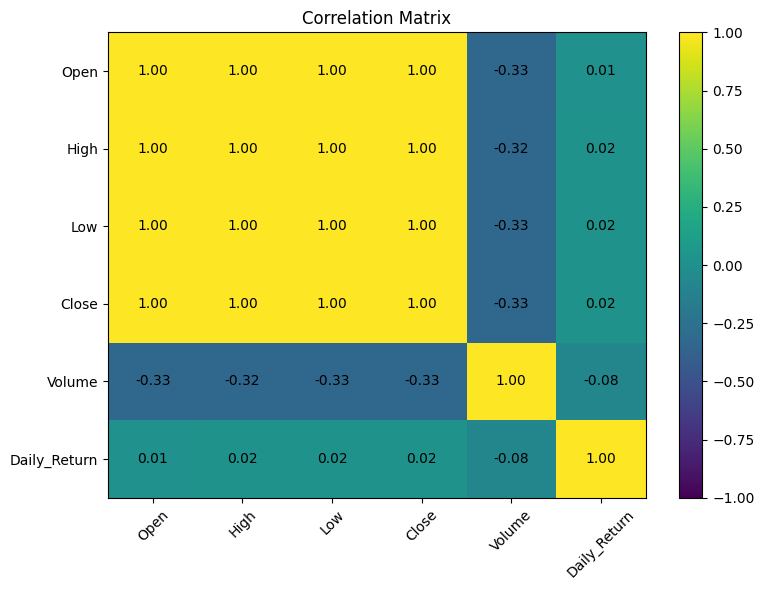

In [21]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    aspect='auto',
    vmin=-1,
    vmax=1
)

plt.colorbar()

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

for i in range(len(correlation_columns)):
    for j in range(len(correlation_columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha='center',
            va='center'
        )

plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

## Feature Engineering

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Technical and relative features are created from the original price and volume data.</li>
<li style="margin:4px 0;">These features provide short-term trend, volatility, and price-movement information for the recurrent models.</li>
</ul>
</div>

In [22]:
df['Volume_Change'] = df['Volume'].pct_change()

df['Open_Close_Pct'] = (
    (df['Close'] - df['Open']) / df['Open']
)

df['High_Low_Pct'] = (
    (df['High'] - df['Low']) / df['Low']
)

In [23]:
df['SMA_5'] = df['Close'].rolling(5).mean()
df['SMA_9'] = df['Close'].rolling(9).mean()
df['SMA_17'] = df['Close'].rolling(17).mean()

df['Close_SMA5_Pct'] = (
    (df['Close'] - df['SMA_5']) / df['SMA_5']
)

df['Close_SMA9_Pct'] = (
    (df['Close'] - df['SMA_9']) / df['SMA_9']
)

df['Close_SMA17_Pct'] = (
    (df['Close'] - df['SMA_17']) / df['SMA_17']
)

In [24]:
rolling_mean = df['Close'].rolling(20).mean()
rolling_std = df['Close'].rolling(20).std()

upper_band = rolling_mean + (2 * rolling_std)
lower_band = rolling_mean - (2 * rolling_std)

df['BB_Width_Pct'] = (
    (upper_band - lower_band) / rolling_mean
)

In [25]:
RETURN_FEATURES = [
    'Daily_Return',
    'Volume_Change',
    'Open_Close_Pct',
    'High_Low_Pct',
    'Close_SMA5_Pct',
    'Close_SMA9_Pct',
    'Close_SMA17_Pct',
    'BB_Width_Pct'
]

df_return = (
    df
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)

print("Feature-engineered dataset shape:", df_return.shape)

df_return[
    ['Date', 'Close'] + RETURN_FEATURES
].head()

Feature-engineered dataset shape: (2668, 17)


,Date,Close,Daily_Return,Volume_Change,Open_Close_Pct,High_Low_Pct,Close_SMA5_Pct,Close_SMA9_Pct,Close_SMA17_Pct,BB_Width_Pct
0,2016-02-01,37.599998,0.012181,0.479204,0.002052,0.019629,0.033268,0.044299,0.049988,0.098035
1,2016-02-02,38.232498,0.016822,0.235231,-0.025303,0.032982,0.035957,0.051129,0.064306,0.109455
2,2016-02-03,36.347500,-0.049304,-0.027898,-0.056179,0.074948,-0.022262,-0.003793,0.010799,0.106322
3,2016-02-04,35.400501,-0.026054,-0.162421,-0.020476,0.035819,-0.041821,-0.027194,-0.014890,0.103168
4,2016-02-05,34.178501,-0.034519,-0.012189,-0.028841,0.035051,-0.059785,-0.056728,-0.045576,0.111762


## Data Preparation for RNN and LSTM

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The dataset is split in chronological order into training, validation, and test periods.</li>
<li style="margin:4px 0;">Scalers are fitted on the training part only, then applied to later periods.</li>
<li style="margin:4px 0;">A fixed lookback window turns the time series into supervised sequences for next-day forecasting.</li>
</ul>
</div>

In [26]:
FEATURE_COLUMNS = [
    'Open',
    'High',
    'Low',
    'Close',
    'Volume',
    'SMA_5',
    'SMA_9',
    'SMA_17',
    'Daily_Return',
    'BB_Width_Pct'
]

TARGET_COLUMN = 'Close'

In [27]:
model_df = df_return[
    ['Date'] + FEATURE_COLUMNS
].copy()

print("Model dataset shape:", model_df.shape)

model_df.head()

Model dataset shape: (2668, 11)


,Date,Open,High,Low,Close,Volume,SMA_5,SMA_9,SMA_17,Daily_Return,BB_Width_Pct
0,2016-02-01,37.522999,37.893002,37.163502,37.599998,102784000,36.389400,36.005000,35.809941,0.012181,0.098035
1,2016-02-02,39.224998,39.493500,38.232498,38.232498,126962000,36.905499,36.372777,35.922470,0.016822,0.109455
2,2016-02-03,38.511002,38.724998,36.025002,36.347500,123420000,37.175099,36.485889,35.959176,-0.049304,0.106322
3,2016-02-04,36.140499,36.349998,35.092999,35.400501,103374000,36.945599,36.390111,35.935588,-0.026054,0.103168
4,2016-02-05,35.193501,35.199501,34.007500,34.178501,102114000,36.351800,36.234000,35.810588,-0.034519,0.111762


In [28]:
print(model_df.isnull().sum())

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
SMA_5           0
SMA_9           0
SMA_17          0
Daily_Return    0
BB_Width_Pct    0
dtype: int64


In [29]:
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10

n = len(model_df)

train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

print("Total samples:", n)

print("Train rows:", train_end)
print("Validation rows:", val_end - train_end)
print("Test rows:", n - val_end)

Total samples: 2668
Train rows: 2134
Validation rows: 267
Test rows: 267


In [30]:
feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

In [31]:
train_features = model_df.iloc[:train_end][FEATURE_COLUMNS]
train_target = model_df.iloc[:train_end][[TARGET_COLUMN]]

feature_scaler.fit(train_features)
target_scaler.fit(train_target)

MinMaxScaler()

In [32]:
features_scaled = feature_scaler.transform(
    model_df[FEATURE_COLUMNS]
)

target_scaled = target_scaler.transform(
    model_df[[TARGET_COLUMN]]
)

In [33]:
print("Scaled features shape:", features_scaled.shape)
print("Scaled target shape:", target_scaled.shape)

print("Feature range:",
      features_scaled.min(),
      features_scaled.max())

print("Target range:",
      target_scaled.min(),
      target_scaled.max())

Scaled features shape: (2668, 10)
Scaled target shape: (2668, 1)
Feature range: -0.006646893173145818 2.3288188535804517
Target range: 0.0 2.2959741646835656


## TensorFlow Data Preparation

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">A 10-day lookback window is used to create sequential inputs.</li>
<li style="margin:4px 0;">Each sequence is paired with the following day's closing price.</li>
<li style="margin:4px 0;">The chronological train, validation, and test boundaries are preserved.</li>
</ul>
</div>

In [34]:
LOOKBACK = 10

In [35]:
def create_sequences(
    features,
    target,
    dates,
    lookback,
    train_end,
    val_end
):
    X_train, y_train = [], []
    X_val, y_val = [], []
    X_test, y_test = [], []
    test_dates = []

    for i in range(lookback, len(features)):

        X = features[i - lookback:i]
        y = target[i]

        if i < train_end:
            X_train.append(X)
            y_train.append(y)

        elif i < val_end:
            X_val.append(X)
            y_val.append(y)

        else:
            X_test.append(X)
            y_test.append(y)
            test_dates.append(dates.iloc[i])

    return (
        np.array(X_train, dtype=np.float32),
        np.array(y_train, dtype=np.float32),
        np.array(X_val, dtype=np.float32),
        np.array(y_val, dtype=np.float32),
        np.array(X_test, dtype=np.float32),
        np.array(y_test, dtype=np.float32),
        np.array(test_dates)
    )

In [36]:
(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    test_dates
) = create_sequences(
    features_scaled,
    target_scaled,
    model_df['Date'],
    LOOKBACK,
    train_end,
    val_end
)

In [37]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (2124, 10, 10)
y_train: (2124, 1)
X_val: (267, 10, 10)
y_val: (267, 1)
X_test: (267, 10, 10)
y_test: (267, 1)


## Simple RNN Model

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">A Simple RNN is used as the first recurrent model for next-day closing-price forecasting.</li>
<li style="margin:4px 0;">The model receives 10-day sequences and produces a single price prediction.</li>
</ul>
</div>

In [38]:
HIDDEN_SIZE = 64
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 100
PATIENCE = 10

INPUT_SIZE = X_train.shape[2]

print("Input size:", INPUT_SIZE)

Input size: 10


In [39]:
rnn_model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, INPUT_SIZE)),

    layers.SimpleRNN(
        HIDDEN_SIZE
    ),

    layers.Dense(1)
])

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,865 (19.00 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
rnn_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss='mse'
)

In [41]:
rnn_early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True
)

In [42]:
rnn_history = rnn_model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=EPOCHS,
    batch_size=BATCH_SIZE,

    callbacks=[
        rnn_early_stopping
    ],

    shuffle=False,
    verbose=1
)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0106 - val_loss: 0.0403
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0173 - val_loss: 0.0051
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0117 - val_loss: 0.0016
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0017 - val_loss: 0.0014
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0010 - val_loss: 0.0012
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026 - val_loss: 0.0016
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0030 - val_loss: 0.0018
Epoch 8/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0033 - val_loss: 0.0027
Epoch 9/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0030 - val_loss: 0.0014
Epoch 10/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031 - val_loss: 0.0020
Epoch 11/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0021 - val_loss: 0.0032
Epoch 12/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9

In [43]:
best_rnn_val_loss = min(
    rnn_history.history['val_loss']
)

print(
    f"Best Simple RNN Validation Loss: "
    f"{best_rnn_val_loss:.6f}"
)

Best Simple RNN Validation Loss: 0.000654


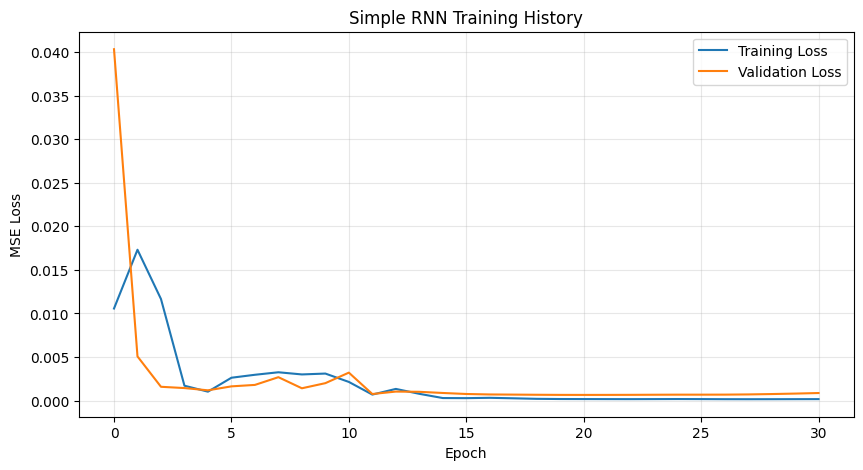

In [44]:
plt.figure(figsize=(10, 5))

plt.plot(
    rnn_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    rnn_history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Simple RNN Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Simple RNN Test Evaluation

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The trained RNN is evaluated on the chronological test period.</li>
<li style="margin:4px 0;">Predictions are converted back to the original price scale before calculating the final error metrics.</li>
</ul>
</div>

In [45]:
rnn_predictions_scaled = rnn_model.predict(
    X_test,
    verbose=0
)

rnn_predictions = target_scaler.inverse_transform(
    rnn_predictions_scaled
).ravel()

rnn_actual = target_scaler.inverse_transform(
    y_test
).ravel()

In [46]:
rnn_mae = mean_absolute_error(
    rnn_actual,
    rnn_predictions
)

rnn_mse = mean_squared_error(
    rnn_actual,
    rnn_predictions
)

rnn_rmse = np.sqrt(rnn_mse)

print(f"Simple RNN MAE: {rnn_mae:.4f}")
print(f"Simple RNN MSE: {rnn_mse:.4f}")
print(f"Simple RNN RMSE: {rnn_rmse:.4f}")

Simple RNN MAE: 33.2313
Simple RNN MSE: 1469.5007
Simple RNN RMSE: 38.3341


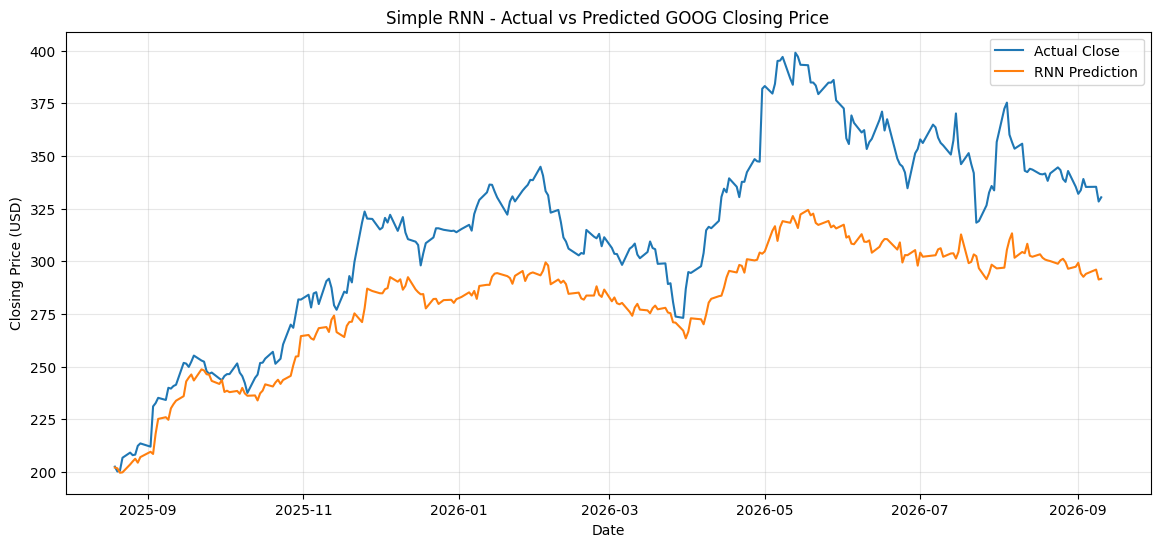

In [47]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    rnn_actual,
    label='Actual Close'
)

plt.plot(
    test_dates,
    rnn_predictions,
    label='RNN Prediction'
)

plt.title('Simple RNN - Actual vs Predicted GOOG Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## LSTM Model

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">An LSTM model is trained using the same input sequences and hyperparameters as the Simple RNN.</li>
<li style="margin:4px 0;">This allows a direct comparison between the two recurrent architectures.</li>
</ul>
</div>

In [48]:
lstm_model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, INPUT_SIZE)),

    layers.LSTM(
        HIDDEN_SIZE
    ),

    layers.Dense(1)
])

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,265 (75.25 KB)

 Trainable params: 19,265 (75.25 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
lstm_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss='mse'
)

In [50]:
lstm_early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True
)

In [51]:
lstm_history = lstm_model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=EPOCHS,
    batch_size=BATCH_SIZE,

    callbacks=[
        lstm_early_stopping
    ],

    shuffle=False,
    verbose=1
)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0011 - val_loss: 0.0118
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0034 - val_loss: 0.0020
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.5270e-04 - val_loss: 0.0014
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3744e-04 - val_loss: 0.0014
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.1909e-04 - val_loss: 0.0013
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4994e-04 - val_loss: 0.0013
Epoch 8/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.2299e-04 - val_loss: 0.0014
Epoch 9/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4050e-04 - val_loss: 0.0014
Epoch 10/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1791e-04 - val_loss: 0.0017
Epoch 11/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.8064e-04 - val_loss: 0.0014
Epoch 12/100
67/67 ━━━━━━━━━━━━

In [52]:
best_lstm_val_loss = min(
    lstm_history.history['val_loss']
)

print(
    f"Best LSTM Validation Loss: "
    f"{best_lstm_val_loss:.6f}"
)

Best LSTM Validation Loss: 0.000864


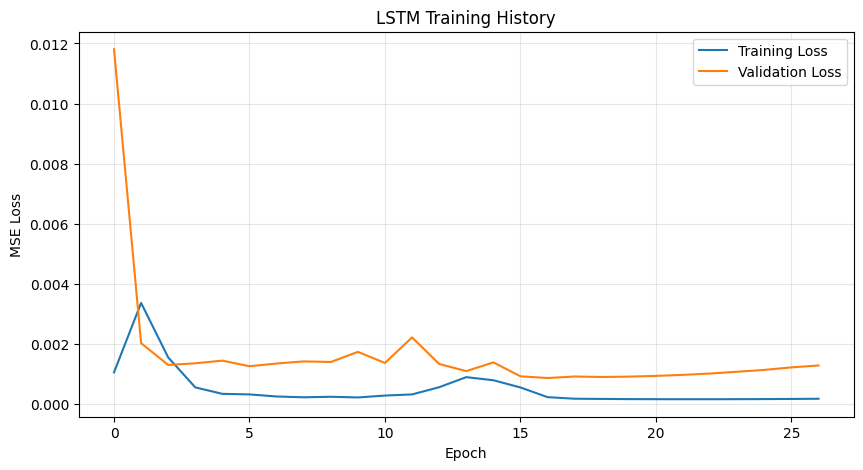

In [53]:
plt.figure(figsize=(10, 5))

plt.plot(
    lstm_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    lstm_history.history['val_loss'],
    label='Validation Loss'
)

plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## LSTM Test Evaluation

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The trained LSTM is evaluated on the same chronological test period as the Simple RNN.</li>
<li style="margin:4px 0;">Predictions are converted back to the original price scale before calculating the error metrics.</li>
</ul>
</div>

In [54]:
lstm_predictions_scaled = lstm_model.predict(
    X_test,
    verbose=0
)

lstm_predictions = target_scaler.inverse_transform(
    lstm_predictions_scaled
).ravel()

lstm_actual = target_scaler.inverse_transform(
    y_test
).ravel()

In [55]:
lstm_mae = mean_absolute_error(
    lstm_actual,
    lstm_predictions
)

lstm_mse = mean_squared_error(
    lstm_actual,
    lstm_predictions
)

lstm_rmse = np.sqrt(lstm_mse)

print(f"LSTM MAE: {lstm_mae:.4f}")
print(f"LSTM MSE: {lstm_mse:.4f}")
print(f"LSTM RMSE: {lstm_rmse:.4f}")

LSTM MAE: 33.9641
LSTM MSE: 1486.0500
LSTM RMSE: 38.5493


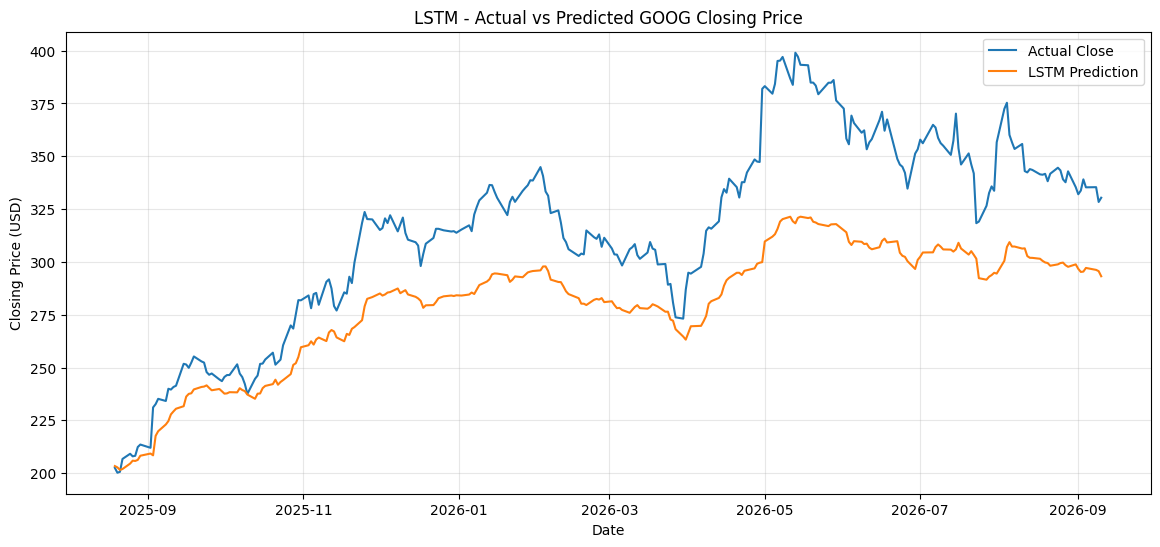

In [56]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    lstm_actual,
    label='Actual Close'
)

plt.plot(
    test_dates,
    lstm_predictions,
    label='LSTM Prediction'
)

plt.title('LSTM - Actual vs Predicted GOOG Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## RNN vs LSTM Comparison

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The Simple RNN and LSTM are compared using the same test period.</li>
<li style="margin:4px 0;">MAE, MSE, and RMSE are used to compare their forecasting performance.</li>
</ul>
</div>

In [57]:
rnn_lstm_comparison = pd.DataFrame({
    'Model': [
        'Simple RNN',
        'LSTM'
    ],

    'MAE': [
        rnn_mae,
        lstm_mae
    ],

    'MSE': [
        rnn_mse,
        lstm_mse
    ],

    'RMSE': [
        rnn_rmse,
        lstm_rmse
    ]
})

rnn_lstm_comparison.round(4)

,Model,MAE,MSE,RMSE
0,Simple RNN,33.2313,1469.5007,38.3341
1,LSTM,33.9641,1486.0500,38.5493


In [58]:
validation_comparison = pd.DataFrame({
    'Model': [
        'Simple RNN',
        'LSTM'
    ],

    'Best Validation Loss': [
        best_rnn_val_loss,
        best_lstm_val_loss
    ]
})

validation_comparison

,Model,Best Validation Loss
0,Simple RNN,0.000654
1,LSTM,0.000864


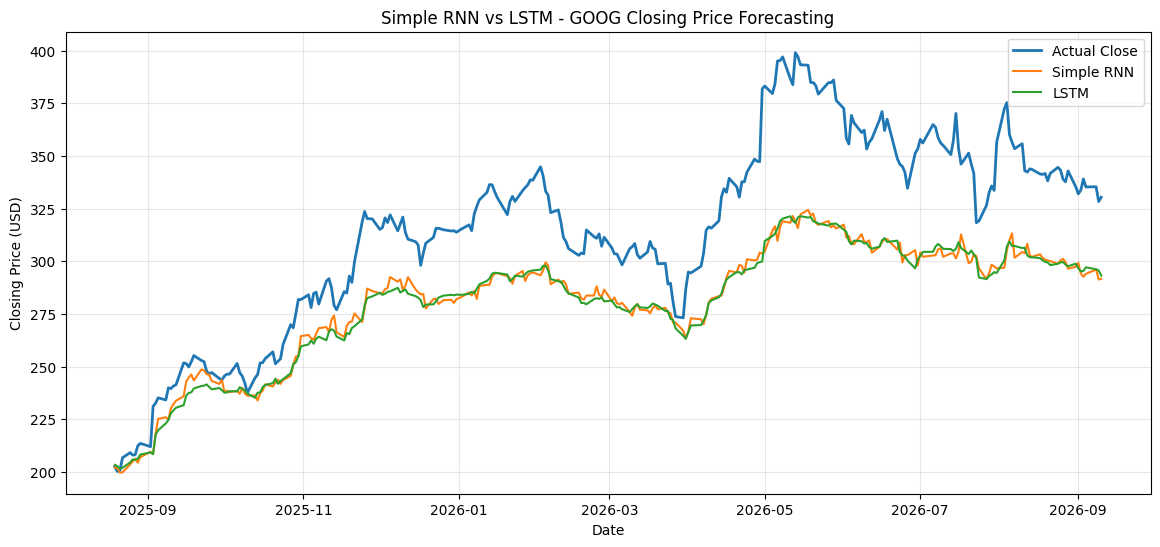

In [59]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    rnn_actual,
    label='Actual Close',
    linewidth=2
)

plt.plot(
    test_dates,
    rnn_predictions,
    label='Simple RNN'
)

plt.plot(
    test_dates,
    lstm_predictions,
    label='LSTM'
)

plt.title('Simple RNN vs LSTM - GOOG Closing Price Forecasting')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Model Comparison

The Simple RNN achieved slightly lower MAE, MSE, and RMSE than the LSTM on the test set.

Both models followed the overall movement of the stock price, but they tended
to underestimate prices during the higher-price periods.

The difference between the two recurrent models was relatively small, while
both remained well behind the naive baseline.

## Naive Baseline Comparison

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">A persistence baseline predicts that the next closing price will be equal to the current closing price.</li>
<li style="margin:4px 0;">RNN and LSTM performance is compared against this simple benchmark on the same test period.</li>
</ul>
</div>

In [60]:
naive_predictions = model_df[
    'Close'
].iloc[
    val_end - 1:-1
].values

naive_actual = model_df[
    'Close'
].iloc[
    val_end:
].values

print("Predictions:", len(naive_predictions))
print("Actual:", len(naive_actual))
print("RNN test samples:", len(rnn_actual))

Predictions: 267
Actual: 267
RNN test samples: 267


In [61]:
baseline_mae = mean_absolute_error(
    naive_actual,
    naive_predictions
)

baseline_mse = mean_squared_error(
    naive_actual,
    naive_predictions
)

baseline_rmse = np.sqrt(
    baseline_mse
)

print(f"Naive Baseline MAE: {baseline_mae:.4f}")
print(f"Naive Baseline MSE: {baseline_mse:.4f}")
print(f"Naive Baseline RMSE: {baseline_rmse:.4f}")

Naive Baseline MAE: 4.4515
Naive Baseline MSE: 40.2299
Naive Baseline RMSE: 6.3427


In [62]:
price_comparison = pd.DataFrame({
    'Model': [
        'Naive Baseline',
        'Simple RNN',
        'LSTM'
    ],

    'MAE': [
        baseline_mae,
        rnn_mae,
        lstm_mae
    ],

    'MSE': [
        baseline_mse,
        rnn_mse,
        lstm_mse
    ],

    'RMSE': [
        baseline_rmse,
        rnn_rmse,
        lstm_rmse
    ]
})

price_comparison.round(4)

,Model,MAE,MSE,RMSE
0,Naive Baseline,4.4515,40.2299,6.3427
1,Simple RNN,33.2313,1469.5007,38.3341
2,LSTM,33.9641,1486.0500,38.5493


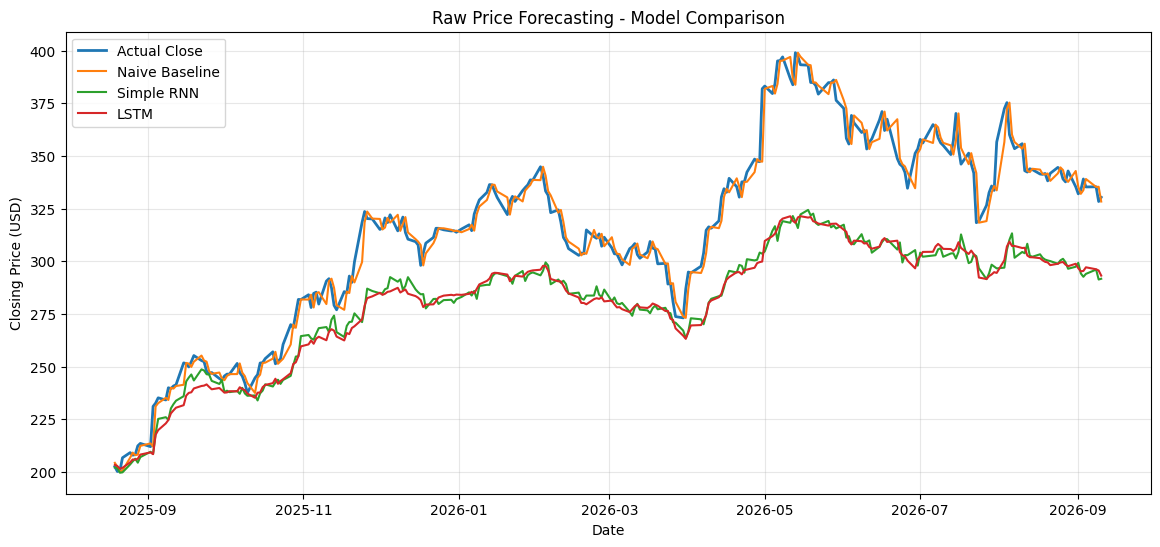

In [63]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    rnn_actual,
    label='Actual Close',
    linewidth=2
)

plt.plot(
    test_dates,
    naive_predictions,
    label='Naive Baseline'
)

plt.plot(
    test_dates,
    rnn_predictions,
    label='Simple RNN'
)

plt.plot(
    test_dates,
    lstm_predictions,
    label='LSTM'
)

plt.title('Raw Price Forecasting - Model Comparison')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Return-Based Forecasting

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Raw-price models struggled to outperform the persistence baseline.</li>
<li style="margin:4px 0;">The forecasting target is therefore changed from the next closing price to the next-day return.</li>
<li style="margin:4px 0;">Relative features are used to reduce the effect of changing price levels over time.</li>
</ul>
</div>

In [64]:
return_df = df_return[
    ['Date', 'Close'] + RETURN_FEATURES
].copy()

return_df['Future_Return_1D'] = (
    return_df['Daily_Return'].shift(-1)
)

return_df = (
    return_df
    .dropna()
    .reset_index(drop=True)
)

return_df.head()

,Date,Close,Daily_Return,Volume_Change,Open_Close_Pct,High_Low_Pct,Close_SMA5_Pct,Close_SMA9_Pct,Close_SMA17_Pct,BB_Width_Pct,Future_Return_1D
0,2016-02-01,37.599998,0.012181,0.479204,0.002052,0.019629,0.033268,0.044299,0.049988,0.098035,0.016822
1,2016-02-02,38.232498,0.016822,0.235231,-0.025303,0.032982,0.035957,0.051129,0.064306,0.109455,-0.049304
2,2016-02-03,36.347500,-0.049304,-0.027898,-0.056179,0.074948,-0.022262,-0.003793,0.010799,0.106322,-0.026054
3,2016-02-04,35.400501,-0.026054,-0.162421,-0.020476,0.035819,-0.041821,-0.027194,-0.014890,0.103168,-0.034519
4,2016-02-05,34.178501,-0.034519,-0.012189,-0.028841,0.035051,-0.059785,-0.056728,-0.045576,0.111762,-0.001214


In [65]:
n_return = len(return_df)

return_train_end = int(
    n_return * 0.80
)

return_val_end = int(
    n_return * 0.90
)

print("Total samples:", n_return)
print("Train:", return_train_end)
print("Validation:", return_val_end - return_train_end)
print("Test:", n_return - return_val_end)

Total samples: 2667
Train: 2133
Validation: 267
Test: 267


In [66]:
return_feature_scaler = StandardScaler()
return_target_scaler = StandardScaler()

return_feature_scaler.fit(
    return_df.iloc[:return_train_end][RETURN_FEATURES]
)

return_target_scaler.fit(
    return_df
    .iloc[:return_train_end - 1][['Future_Return_1D']]
)

return_features_scaled = (
    return_feature_scaler.transform(
        return_df[RETURN_FEATURES]
    )
)

return_target_scaled = (
    return_target_scaler.transform(
        return_df[['Future_Return_1D']]
    )
)

In [67]:
RETURN_LOOKBACK = 10

## Return-Based Sequence Creation

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Ten-day sequences are created from the relative return-based features.</li>
<li style="margin:4px 0;">The target is the following day's GOOG return.</li>
<li style="margin:4px 0;">Current and next-day closing prices are also stored for later price reconstruction.</li>
</ul>
</div>

In [68]:
def create_return_sequences(
    features,
    target,
    dates,
    close_prices,
    lookback,
    train_end,
    val_end
):
    X_train, y_train = [], []
    X_val, y_val = [], []
    X_test, y_test = [], []

    test_dates = []
    test_current_close = []
    test_next_close = []

    for i in range(lookback - 1, len(features) - 1):

        X = features[
            i - lookback + 1:i + 1
        ]

        y = target[i]

        if i < train_end - 1:
            X_train.append(X)
            y_train.append(y)

        elif i >= train_end and i < val_end - 1:
            X_val.append(X)
            y_val.append(y)

        elif i >= val_end:
            X_test.append(X)
            y_test.append(y)

            test_dates.append(
                dates.iloc[i + 1]
            )

            test_current_close.append(
                close_prices.iloc[i]
            )

            test_next_close.append(
                close_prices.iloc[i + 1]
            )

    return (
        np.array(X_train, dtype=np.float32),
        np.array(y_train, dtype=np.float32),
        np.array(X_val, dtype=np.float32),
        np.array(y_val, dtype=np.float32),
        np.array(X_test, dtype=np.float32),
        np.array(y_test, dtype=np.float32),
        np.array(test_dates),
        np.array(test_current_close),
        np.array(test_next_close)
    )

In [69]:
(
    X_train_return,
    y_train_return,
    X_val_return,
    y_val_return,
    X_test_return,
    y_test_return,
    test_dates_return,
    test_current_close_return,
    test_next_close_return
) = create_return_sequences(
    return_features_scaled,
    return_target_scaled,
    return_df['Date'],
    return_df['Close'],
    RETURN_LOOKBACK,
    return_train_end,
    return_val_end
)

In [70]:
print("X_train:", X_train_return.shape)
print("y_train:", y_train_return.shape)

print("X_val:", X_val_return.shape)
print("y_val:", y_val_return.shape)

print("X_test:", X_test_return.shape)
print("y_test:", y_test_return.shape)

X_train: (2123, 10, 8)
y_train: (2123, 1)
X_val: (266, 10, 8)
y_val: (266, 1)
X_test: (266, 10, 8)
y_test: (266, 1)


## Return-Based Simple RNN

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The Simple RNN is now trained to predict the next-day return instead of the raw closing price.</li>
<li style="margin:4px 0;">The same lookback window and chronological split are preserved.</li>
</ul>
</div>

In [71]:
RETURN_INPUT_SIZE = X_train_return.shape[2]

print("Return input size:", RETURN_INPUT_SIZE)

Return input size: 8


In [72]:
return_rnn_model = keras.Sequential([
    layers.Input(
        shape=(RETURN_LOOKBACK, RETURN_INPUT_SIZE)
    ),

    layers.SimpleRNN(
        HIDDEN_SIZE
    ),

    layers.Dense(1)
])

return_rnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         4,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
return_rnn_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss='mse'
)

In [74]:
return_rnn_early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True
)

In [75]:
return_rnn_history = return_rnn_model.fit(
    X_train_return,
    y_train_return,

    validation_data=(
        X_val_return,
        y_val_return
    ),

    epochs=EPOCHS,
    batch_size=BATCH_SIZE,

    callbacks=[
        return_rnn_early_stopping
    ],

    shuffle=False,
    verbose=1
)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0803 - val_loss: 1.1966
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0061 - val_loss: 1.1927
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9730 - val_loss: 1.1956
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9483 - val_loss: 1.2002
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9268 - val_loss: 1.2066
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9065 - val_loss: 1.2144
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8864 - val_loss: 1.2233
Epoch 8/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8658 - val_loss: 1.2333
Epoch 9/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8440 - val_loss: 1.2450
Epoch 10/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8206 - val_loss: 1.2589
Epoch 11/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7955 - val_loss: 1.2753
Epoch 12/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7

In [76]:
best_return_rnn_val_loss = min(
    return_rnn_history.history['val_loss']
)

print(
    f"Best Return RNN Validation Loss: "
    f"{best_return_rnn_val_loss:.6f}"
)

Best Return RNN Validation Loss: 1.192724


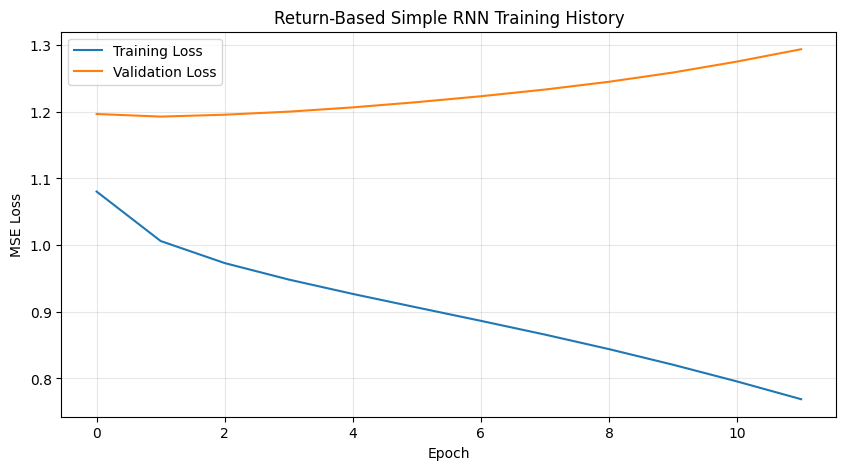

In [77]:
plt.figure(figsize=(10, 5))

plt.plot(
    return_rnn_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    return_rnn_history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Return-Based Simple RNN Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Return-Based RNN Test Evaluation

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Predicted returns are converted back to their original scale.</li>
<li style="margin:4px 0;">The predicted next-day return is then used to reconstruct the next closing price.</li>
</ul>
</div>

In [78]:
return_rnn_predictions_scaled = return_rnn_model.predict(
    X_test_return,
    verbose=0
)

return_rnn_predicted_returns = (
    return_target_scaler
    .inverse_transform(return_rnn_predictions_scaled)
    .ravel()
)

return_rnn_actual_returns = (
    return_target_scaler
    .inverse_transform(y_test_return)
    .ravel()
)

In [79]:
return_rnn_price_predictions = (
    test_current_close_return *
    (1 + return_rnn_predicted_returns)
)

In [80]:
return_rnn_mae = mean_absolute_error(
    test_next_close_return,
    return_rnn_price_predictions
)

return_rnn_mse = mean_squared_error(
    test_next_close_return,
    return_rnn_price_predictions
)

return_rnn_rmse = np.sqrt(
    return_rnn_mse
)

print(f"Return-Based RNN MAE: {return_rnn_mae:.4f}")
print(f"Return-Based RNN MSE: {return_rnn_mse:.4f}")
print(f"Return-Based RNN RMSE: {return_rnn_rmse:.4f}")

Return-Based RNN MAE: 4.6656
Return-Based RNN MSE: 43.2218
Return-Based RNN RMSE: 6.5743


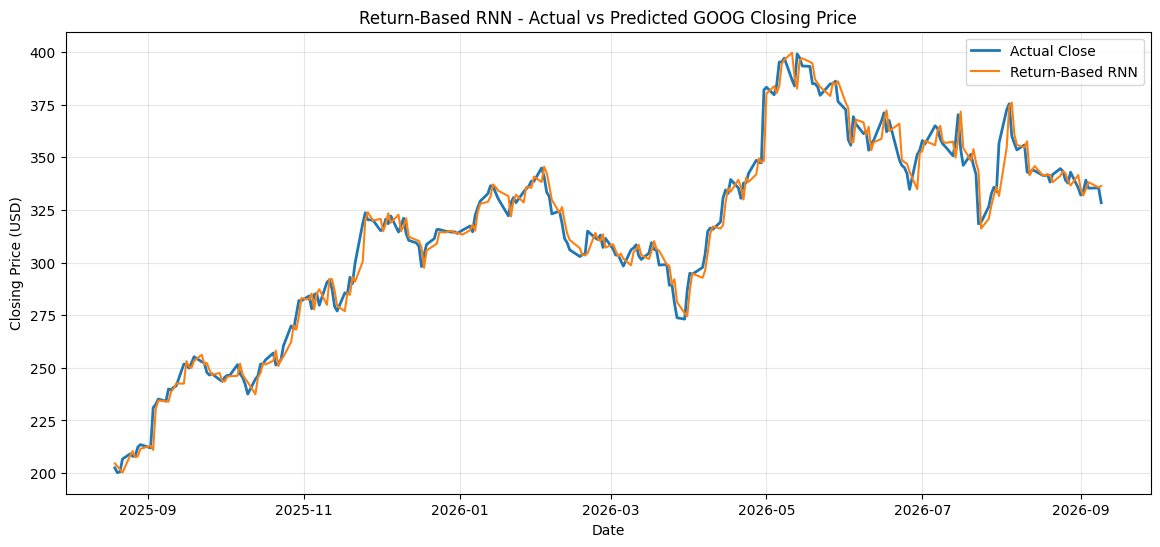

In [81]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates_return,
    test_next_close_return,
    label='Actual Close',
    linewidth=2
)

plt.plot(
    test_dates_return,
    return_rnn_price_predictions,
    label='Return-Based RNN'
)

plt.title('Return-Based RNN - Actual vs Predicted GOOG Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Return-Based LSTM

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The LSTM is trained on the same return-based sequences used for the Simple RNN.</li>
<li style="margin:4px 0;">This keeps the comparison between both recurrent models consistent.</li>
</ul>
</div>

In [82]:
return_lstm_model = keras.Sequential([
    layers.Input(
        shape=(RETURN_LOOKBACK, RETURN_INPUT_SIZE)
    ),

    layers.LSTM(
        HIDDEN_SIZE
    ),

    layers.Dense(1)
])

return_lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,753 (73.25 KB)

 Trainable params: 18,753 (73.25 KB)

 Non-trainable params: 0 (0.00 B)

In [83]:
return_lstm_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss='mse'
)

In [84]:
return_lstm_early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True
)

In [85]:
return_lstm_history = return_lstm_model.fit(
    X_train_return,
    y_train_return,

    validation_data=(
        X_val_return,
        y_val_return
    ),

    epochs=EPOCHS,
    batch_size=BATCH_SIZE,

    callbacks=[
        return_lstm_early_stopping
    ],

    shuffle=False,
    verbose=1
)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.0063 - val_loss: 1.1447
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9867 - val_loss: 1.1433
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9770 - val_loss: 1.1422
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9694 - val_loss: 1.1426
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9626 - val_loss: 1.1437
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9559 - val_loss: 1.1456
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9488 - val_loss: 1.1495
Epoch 8/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9411 - val_loss: 1.1545
Epoch 9/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9320 - val_loss: 1.1653
Epoch 10/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9220 - val_loss: 1.1747
Epoch 11/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9115 - val_loss: 1.1982
Epoch 12/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9

In [86]:
best_return_lstm_val_loss = min(
    return_lstm_history.history['val_loss']
)

print(
    f"Best Return LSTM Validation Loss: "
    f"{best_return_lstm_val_loss:.6f}"
)

Best Return LSTM Validation Loss: 1.142227


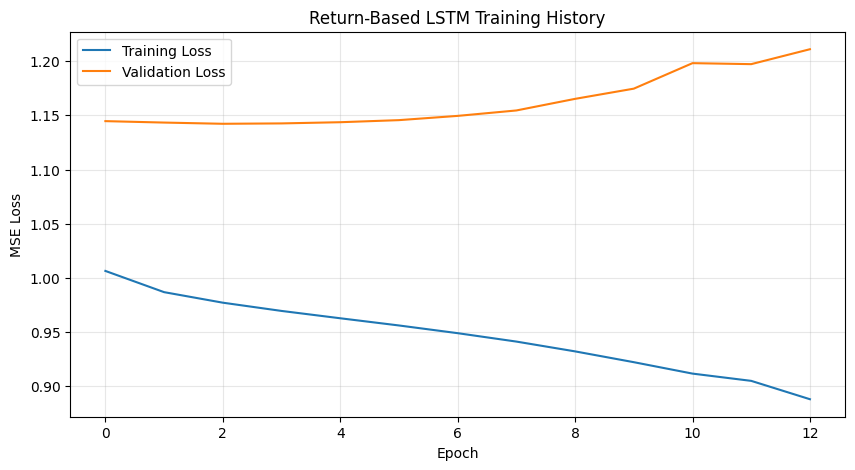

In [87]:
plt.figure(figsize=(10, 5))

plt.plot(
    return_lstm_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    return_lstm_history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Return-Based LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Return-Based LSTM Test Evaluation

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Predicted returns are transformed back to their original scale.</li>
<li style="margin:4px 0;">The predicted return is then used to reconstruct the next-day closing price.</li>
</ul>
</div>

In [88]:
return_lstm_predictions_scaled = return_lstm_model.predict(
    X_test_return,
    verbose=0
)

return_lstm_predicted_returns = (
    return_target_scaler
    .inverse_transform(return_lstm_predictions_scaled)
    .ravel()
)

return_lstm_actual_returns = (
    return_target_scaler
    .inverse_transform(y_test_return)
    .ravel()
)

In [89]:
return_lstm_price_predictions = (
    test_current_close_return *
    (1 + return_lstm_predicted_returns)
)

In [90]:
return_lstm_mae = mean_absolute_error(
    test_next_close_return,
    return_lstm_price_predictions
)

return_lstm_mse = mean_squared_error(
    test_next_close_return,
    return_lstm_price_predictions
)

return_lstm_rmse = np.sqrt(
    return_lstm_mse
)

print(f"Return-Based LSTM MAE: {return_lstm_mae:.4f}")
print(f"Return-Based LSTM MSE: {return_lstm_mse:.4f}")
print(f"Return-Based LSTM RMSE: {return_lstm_rmse:.4f}")

Return-Based LSTM MAE: 4.5938
Return-Based LSTM MSE: 41.7723
Return-Based LSTM RMSE: 6.4632


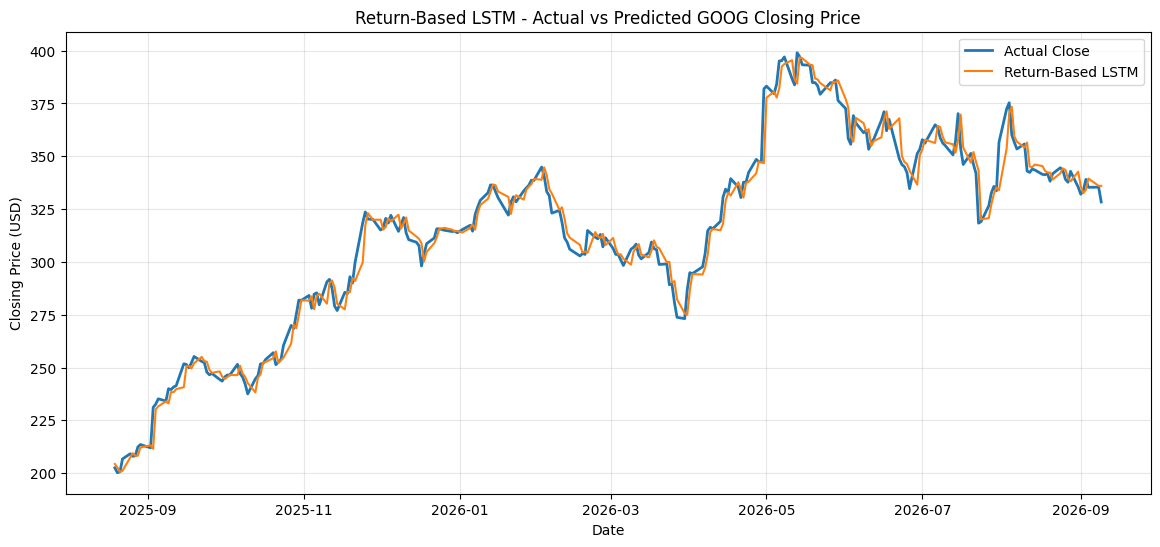

In [91]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates_return,
    test_next_close_return,
    label='Actual Close',
    linewidth=2
)

plt.plot(
    test_dates_return,
    return_lstm_price_predictions,
    label='Return-Based LSTM'
)

plt.title('Return-Based LSTM - Actual vs Predicted GOOG Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Return-Based RNN vs LSTM

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The return-based RNN and LSTM are compared on the same test period.</li>
<li style="margin:4px 0;">Their reconstructed next-day closing prices are evaluated using MAE, MSE, and RMSE.</li>
</ul>
</div>

In [92]:
return_model_comparison = pd.DataFrame({
    'Model': [
        'Return-Based RNN',
        'Return-Based LSTM'
    ],

    'MAE': [
        return_rnn_mae,
        return_lstm_mae
    ],

    'MSE': [
        return_rnn_mse,
        return_lstm_mse
    ],

    'RMSE': [
        return_rnn_rmse,
        return_lstm_rmse
    ]
})

return_model_comparison.round(4)

,Model,MAE,MSE,RMSE
0,Return-Based RNN,4.6656,43.2218,6.5743
1,Return-Based LSTM,4.5938,41.7723,6.4632


In [93]:
return_validation_comparison = pd.DataFrame({
    'Model': [
        'Return-Based RNN',
        'Return-Based LSTM'
    ],

    'Best Validation Loss': [
        best_return_rnn_val_loss,
        best_return_lstm_val_loss
    ]
})

return_validation_comparison.round(6)

,Model,Best Validation Loss
0,Return-Based RNN,1.192724
1,Return-Based LSTM,1.142227


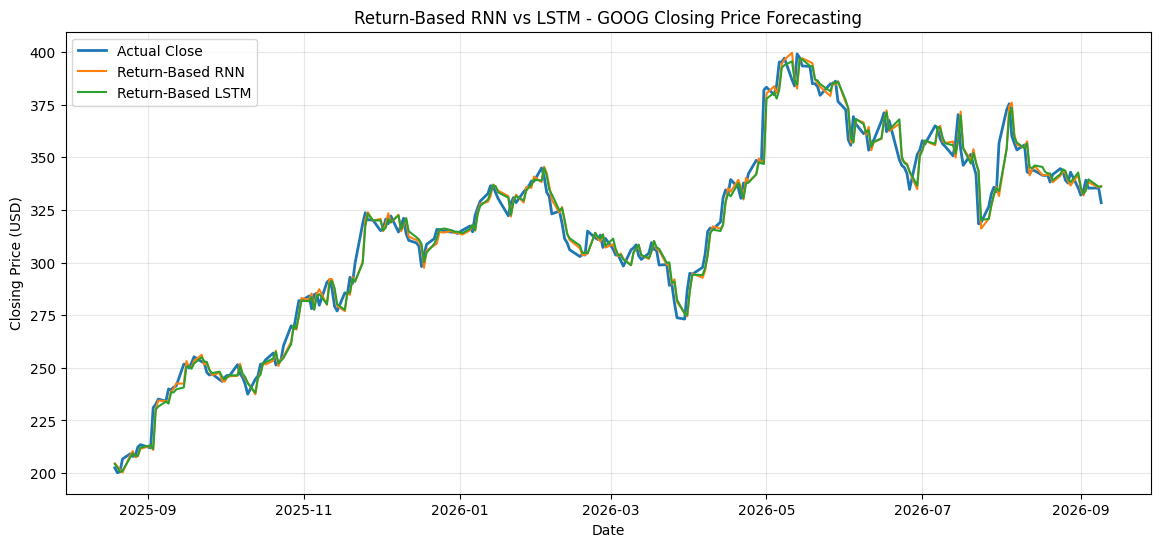

In [94]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates_return,
    test_next_close_return,
    label='Actual Close',
    linewidth=2
)

plt.plot(
    test_dates_return,
    return_rnn_price_predictions,
    label='Return-Based RNN'
)

plt.plot(
    test_dates_return,
    return_lstm_price_predictions,
    label='Return-Based LSTM'
)

plt.title('Return-Based RNN vs LSTM - GOOG Closing Price Forecasting')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Predictability Check

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Before adding more model complexity, the available features are checked for next-day return signal.</li>
<li style="margin:4px 0;">Lag correlations and feature correlations help show whether the current information contains useful predictive structure.</li>
</ul>
</div>

In [95]:
diagnostic_df = df_return.copy()

diagnostic_df['Future_Return_1D'] = (
    diagnostic_df['Daily_Return'].shift(-1)
)

diagnostic_df = (
    diagnostic_df
    .dropna()
    .reset_index(drop=True)
)

diagnostic_df.head()

,Date,Open,High,Low,Close,Volume,Daily_Return,Volume_Change,Open_Close_Pct,High_Low_Pct,SMA_5,SMA_9,SMA_17,Close_SMA5_Pct,Close_SMA9_Pct,Close_SMA17_Pct,BB_Width_Pct,Future_Return_1D
0,2016-02-01,37.522999,37.893002,37.163502,37.599998,102784000,0.012181,0.479204,0.002052,0.019629,36.389400,36.005000,35.809941,0.033268,0.044299,0.049988,0.098035,0.016822
1,2016-02-02,39.224998,39.493500,38.232498,38.232498,126962000,0.016822,0.235231,-0.025303,0.032982,36.905499,36.372777,35.922470,0.035957,0.051129,0.064306,0.109455,-0.049304
2,2016-02-03,38.511002,38.724998,36.025002,36.347500,123420000,-0.049304,-0.027898,-0.056179,0.074948,37.175099,36.485889,35.959176,-0.022262,-0.003793,0.010799,0.106322,-0.026054
3,2016-02-04,36.140499,36.349998,35.092999,35.400501,103374000,-0.026054,-0.162421,-0.020476,0.035819,36.945599,36.390111,35.935588,-0.041821,-0.027194,-0.014890,0.103168,-0.034519
4,2016-02-05,35.193501,35.199501,34.007500,34.178501,102114000,-0.034519,-0.012189,-0.028841,0.035051,36.351800,36.234000,35.810588,-0.059785,-0.056728,-0.045576,0.111762,-0.001214


In [96]:
lag_correlations = {}

for lag in range(1, 11):

    lagged_return = (
        diagnostic_df['Daily_Return'].shift(lag)
    )

    correlation = lagged_return.corr(
        diagnostic_df['Future_Return_1D']
    )

    lag_correlations[f'Lag_{lag}'] = correlation

lag_correlation_df = pd.DataFrame(
    lag_correlations.items(),
    columns=['Lag', 'Correlation']
)

lag_correlation_df

,Lag,Correlation
0,Lag_1,-0.002722
1,Lag_2,-0.023571
2,Lag_3,-0.015344
3,Lag_4,-0.007969
4,Lag_5,-0.054155
5,Lag_6,0.034100
6,Lag_7,-0.047630
7,Lag_8,0.066800
8,Lag_9,-0.004605
9,Lag_10,-0.012963


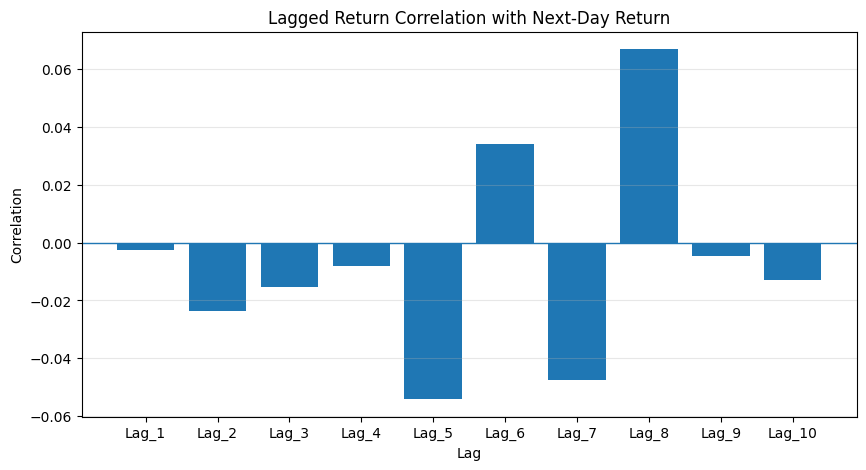

In [97]:
plt.figure(figsize=(10, 5))

plt.bar(
    lag_correlation_df['Lag'],
    lag_correlation_df['Correlation']
)

plt.axhline(
    0,
    linewidth=1
)

plt.title('Lagged Return Correlation with Next-Day Return')
plt.xlabel('Lag')
plt.ylabel('Correlation')

plt.grid(
    axis='y',
    alpha=0.3
)

plt.show()

In [98]:
pearson_correlations = (
    diagnostic_df[
        RETURN_FEATURES + ['Future_Return_1D']
    ]
    .corr(method='pearson')
    ['Future_Return_1D']
    .drop('Future_Return_1D')
    .sort_values(key=abs, ascending=False)
)

pearson_correlations

Close_SMA9_Pct    -0.058689
Open_Close_Pct    -0.054484
Close_SMA17_Pct   -0.049081
Close_SMA5_Pct    -0.047989
Daily_Return      -0.047279
Volume_Change      0.005963
BB_Width_Pct      -0.002585
High_Low_Pct      -0.002001
Name: Future_Return_1D, dtype: float64

In [99]:
spearman_correlations = (
    diagnostic_df[
        RETURN_FEATURES + ['Future_Return_1D']
    ]
    .corr(method='spearman')
    ['Future_Return_1D']
    .drop('Future_Return_1D')
    .sort_values(key=abs, ascending=False)
)

spearman_correlations

Close_SMA9_Pct    -0.042836
Close_SMA17_Pct   -0.042471
Open_Close_Pct    -0.029923
Close_SMA5_Pct    -0.027010
BB_Width_Pct      -0.017812
Volume_Change     -0.008066
Daily_Return      -0.006357
High_Low_Pct       0.002288
Name: Future_Return_1D, dtype: float64

In [100]:
predictability_summary = pd.DataFrame({
    'Pearson': pearson_correlations,
    'Spearman': spearman_correlations
})

predictability_summary

,Pearson,Spearman
BB_Width_Pct,-0.002585,-0.017812
Close_SMA17_Pct,-0.049081,-0.042471
Close_SMA5_Pct,-0.047989,-0.027010
Close_SMA9_Pct,-0.058689,-0.042836
Daily_Return,-0.047279,-0.006357
High_Low_Pct,-0.002001,0.002288
Open_Close_Pct,-0.054484,-0.029923
Volume_Change,0.005963,-0.008066


## Adding Market Context

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Broader market information is added to provide context beyond Google's own price history.</li>
<li style="margin:4px 0;">QQQ, SPY, and VIX are used to represent technology-market movement, broad-market movement, and market volatility.</li>
</ul>
</div>

In [101]:
market_start = df['Date'].min().strftime('%Y-%m-%d')
market_end = (df['Date'].max() + pd.Timedelta(days=1)).strftime('%Y-%m-%d')

qqq = yf.download(
    'QQQ',
    start=market_start,
    end=market_end,
    auto_adjust=False,
    progress=False
)

spy = yf.download(
    'SPY',
    start=market_start,
    end=market_end,
    auto_adjust=False,
    progress=False
)

vix = yf.download(
    '^VIX',
    start=market_start,
    end=market_end,
    auto_adjust=False,
    progress=False
)

In [102]:
def clean_market_data(data):

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    data = data.reset_index()

    return data


qqq = clean_market_data(qqq)
spy = clean_market_data(spy)
vix = clean_market_data(vix)

print("QQQ:", qqq.shape)
print("SPY:", spy.shape)
print("VIX:", vix.shape)

QQQ: (2687, 7)
SPY: (2687, 7)
VIX: (2689, 7)


## Market Feature Engineering

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Daily market-return and volatility features are created from QQQ, SPY, and VIX.</li>
<li style="margin:4px 0;">These features are merged with the GOOG return-based dataset using the trading date.</li>
</ul>
</div>

In [103]:
qqq['QQQ_Return'] = qqq['Close'].pct_change()

qqq['QQQ_Volume_Change'] = (
    qqq['Volume'].pct_change()
)

qqq['QQQ_Volatility_5'] = (
    qqq['QQQ_Return']
    .rolling(5)
    .std()
)

qqq_features = qqq[
    [
        'Date',
        'QQQ_Return',
        'QQQ_Volume_Change',
        'QQQ_Volatility_5'
    ]
].copy()

In [104]:
spy['SPY_Return'] = spy['Close'].pct_change()

spy['SPY_Volatility_5'] = (
    spy['SPY_Return']
    .rolling(5)
    .std()
)

spy_features = spy[
    [
        'Date',
        'SPY_Return',
        'SPY_Volatility_5'
    ]
].copy()

In [105]:
vix['VIX_Return'] = vix['Close'].pct_change()

vix['VIX_Level'] = vix['Close']

vix_features = vix[
    [
        'Date',
        'VIX_Level',
        'VIX_Return'
    ]
].copy()

In [106]:
market_df = (
    qqq_features
    .merge(
        spy_features,
        on='Date',
        how='inner'
    )
    .merge(
        vix_features,
        on='Date',
        how='inner'
    )
)

market_df = (
    market_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)

print("Market dataset shape:", market_df.shape)

market_df.head()

Market dataset shape: (2682, 8)


Price,Date,QQQ_Return,QQQ_Volume_Change,QQQ_Volatility_5,SPY_Return,SPY_Volatility_5,VIX_Level,VIX_Return
0,2016-01-11,0.003077,-0.278610,0.013191,0.000990,0.010675,24.299999,-0.100333
1,2016-01-12,0.011598,-0.065766,0.016177,0.008068,0.012495,22.469999,-0.075309
2,2016-01-13,-0.034489,0.495066,0.020477,-0.024941,0.014723,25.219999,0.122385
3,2016-01-14,0.021295,0.122727,0.021478,0.016417,0.016250,23.950001,-0.050357
4,2016-01-15,-0.031037,0.165697,0.025375,-0.021466,0.018240,27.020000,0.128184


In [107]:
MARKET_FEATURES = [
    'QQQ_Return',
    'QQQ_Volume_Change',
    'QQQ_Volatility_5',
    'SPY_Return',
    'SPY_Volatility_5',
    'VIX_Level',
    'VIX_Return'
]

print("Number of market features:", len(MARKET_FEATURES))

Number of market features: 7


In [108]:
enhanced_df = (
    df_return
    .merge(
        market_df,
        on='Date',
        how='inner'
    )
)

enhanced_df = (
    enhanced_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)

print("Enhanced dataset shape:", enhanced_df.shape)
print("Missing values:", enhanced_df.isnull().sum().sum())

Enhanced dataset shape: (2668, 24)
Missing values: 0


## Market Context Predictability Check

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The original GOOG features are combined with the new market-context features.</li>
<li style="margin:4px 0;">Pearson and Spearman correlations are checked against the next-day return.</li>
<li style="margin:4px 0;">Feature selection is based on the development period rather than the final test period.</li>
</ul>
</div>

In [109]:
ENHANCED_FEATURES = (
    RETURN_FEATURES +
    MARKET_FEATURES
)

print(
    "Total enhanced features:",
    len(ENHANCED_FEATURES)
)

Total enhanced features: 15


In [110]:
enhanced_diagnostic = enhanced_df.copy()

enhanced_diagnostic['Future_Return_1D'] = (
    enhanced_diagnostic['Daily_Return'].shift(-1)
)

enhanced_diagnostic = (
    enhanced_diagnostic
    .dropna()
    .reset_index(drop=True)
)

In [111]:
enhanced_pearson = (
    enhanced_diagnostic[
        ENHANCED_FEATURES + ['Future_Return_1D']
    ]
    .corr(method='pearson')
    ['Future_Return_1D']
    .drop('Future_Return_1D')
    .sort_values(key=abs, ascending=False)
)

enhanced_pearson

SPY_Return          -0.101846
QQQ_Return          -0.078608
Close_SMA9_Pct      -0.058689
Open_Close_Pct      -0.054484
Close_SMA17_Pct     -0.049081
Close_SMA5_Pct      -0.047989
Daily_Return        -0.047279
VIX_Level            0.039206
VIX_Return           0.036882
QQQ_Volatility_5    -0.029789
SPY_Volatility_5    -0.021550
QQQ_Volume_Change   -0.011042
Volume_Change        0.005963
BB_Width_Pct        -0.002585
High_Low_Pct        -0.002001
Name: Future_Return_1D, dtype: float64

In [112]:
enhanced_spearman = (
    enhanced_diagnostic[
        ENHANCED_FEATURES + ['Future_Return_1D']
    ]
    .corr(method='spearman')
    ['Future_Return_1D']
    .drop('Future_Return_1D')
    .sort_values(key=abs, ascending=False)
)

enhanced_spearman

Close_SMA9_Pct      -0.042836
Close_SMA17_Pct     -0.042471
Open_Close_Pct      -0.029923
SPY_Return          -0.027727
Close_SMA5_Pct      -0.027010
VIX_Level            0.024257
SPY_Volatility_5     0.021224
BB_Width_Pct        -0.017812
QQQ_Return          -0.016352
QQQ_Volume_Change   -0.011262
Volume_Change       -0.008066
Daily_Return        -0.006357
High_Low_Pct         0.002288
QQQ_Volatility_5    -0.001734
VIX_Return          -0.000740
Name: Future_Return_1D, dtype: float64

In [113]:
development_end = int(
    len(enhanced_diagnostic) * 0.90
)

development_df = (
    enhanced_diagnostic
    .iloc[:development_end]
    .copy()
)

In [114]:
development_pearson = (
    development_df[
        ENHANCED_FEATURES + ['Future_Return_1D']
    ]
    .corr(method='pearson')
    ['Future_Return_1D']
    .drop('Future_Return_1D')
    .sort_values(key=abs, ascending=False)
)

development_pearson

SPY_Return          -0.112250
QQQ_Return          -0.088860
Close_SMA9_Pct      -0.075712
Open_Close_Pct      -0.065439
Close_SMA17_Pct     -0.064475
Close_SMA5_Pct      -0.064233
Daily_Return        -0.063139
VIX_Return           0.039151
VIX_Level            0.036513
QQQ_Volatility_5    -0.032438
SPY_Volatility_5    -0.025811
BB_Width_Pct        -0.017104
QQQ_Volume_Change   -0.016667
Volume_Change        0.005392
High_Low_Pct        -0.004202
Name: Future_Return_1D, dtype: float64

In [115]:
development_spearman = (
    development_df[
        ENHANCED_FEATURES + ['Future_Return_1D']
    ]
    .corr(method='spearman')
    ['Future_Return_1D']
    .drop('Future_Return_1D')
    .sort_values(key=abs, ascending=False)
)

development_spearman

Close_SMA17_Pct     -0.057599
Close_SMA9_Pct      -0.057213
Close_SMA5_Pct      -0.043738
Open_Close_Pct      -0.038733
SPY_Return          -0.035207
BB_Width_Pct        -0.025172
QQQ_Return          -0.023226
VIX_Level            0.022811
QQQ_Volume_Change   -0.020785
Daily_Return        -0.014628
SPY_Volatility_5     0.013757
Volume_Change       -0.005372
QQQ_Volatility_5    -0.002554
High_Low_Pct         0.001743
VIX_Return          -0.000572
Name: Future_Return_1D, dtype: float64

## Enhanced Return Forecasting

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The final feature set combines GOOG-specific signals with broader market information.</li>
<li style="margin:4px 0;">Feature selection is based on the development period, while the final test period remains untouched.</li>
<li style="margin:4px 0;">The target remains the next-day GOOG return.</li>
</ul>
</div>

In [116]:
FINAL_FEATURES = [
    'SPY_Return',
    'QQQ_Return',
    'Close_SMA9_Pct',
    'Open_Close_Pct',
    'Close_SMA17_Pct',
    'Close_SMA5_Pct',
    'Daily_Return',
    'VIX_Return',
    'VIX_Level',
    'QQQ_Volatility_5'
]

print("Number of final features:", len(FINAL_FEATURES))

Number of final features: 10


In [117]:
final_df = enhanced_df[
    ['Date', 'Close'] + FINAL_FEATURES
].copy()

final_df['Future_Return_1D'] = (
    final_df['Daily_Return'].shift(-1)
)

final_df = (
    final_df
    .dropna()
    .reset_index(drop=True)
)

print("Final dataset shape:", final_df.shape)

final_df.head()

Final dataset shape: (2667, 13)


,Date,Close,SPY_Return,QQQ_Return,Close_SMA9_Pct,Open_Close_Pct,Close_SMA17_Pct,Close_SMA5_Pct,Daily_Return,VIX_Return,VIX_Level,QQQ_Volatility_5,Future_Return_1D
0,2016-02-01,37.599998,-0.000361,0.002689,0.044299,0.002052,0.049988,0.033268,0.012181,-0.010891,19.980000,0.017675,0.016822
1,2016-02-02,38.232498,-0.018022,-0.021645,0.051129,-0.025303,0.064306,0.035957,0.016822,0.100100,21.980000,0.020713,-0.049304
2,2016-02-03,36.347500,0.005995,-0.004797,-0.003793,-0.056179,0.010799,-0.022262,-0.049304,-0.015014,21.650000,0.016650,-0.026054
3,2016-02-04,35.400501,0.001568,-0.000098,-0.027194,-0.020476,-0.014890,-0.041821,-0.026054,0.008776,21.840000,0.015273,-0.034519
4,2016-02-05,34.178501,-0.019050,-0.034727,-0.056728,-0.028841,-0.045576,-0.059785,-0.034519,0.070513,23.379999,0.015957,-0.001214


In [118]:
n_final = len(final_df)

final_train_end = int(n_final * 0.80)
final_val_end = int(n_final * 0.90)

print("Train:", final_train_end)
print("Validation:", final_val_end - final_train_end)
print("Test:", n_final - final_val_end)

Train: 2133
Validation: 267
Test: 267


In [119]:
final_feature_scaler = StandardScaler()
final_target_scaler = StandardScaler()

final_feature_scaler.fit(
    final_df.iloc[:final_train_end][FINAL_FEATURES]
)

final_target_scaler.fit(
    final_df
    .iloc[:final_train_end - 1][['Future_Return_1D']]
)

final_features_scaled = (
    final_feature_scaler.transform(
        final_df[FINAL_FEATURES]
    )
)

final_target_scaled = (
    final_target_scaler.transform(
        final_df[['Future_Return_1D']]
    )
)

In [120]:
FINAL_LOOKBACK = 10

In [121]:
def create_final_sequences(
    features,
    target,
    dates,
    close_prices,
    lookback,
    train_end,
    val_end
):
    X_train, y_train = [], []
    X_val, y_val = [], []
    X_test, y_test = [], []

    test_dates = []
    test_current_close = []
    test_next_close = []

    for i in range(lookback - 1, len(features) - 1):

        X = features[
            i - lookback + 1:i + 1
        ]

        y = target[i]

        if i < train_end - 1:
            X_train.append(X)
            y_train.append(y)

        elif i >= train_end and i < val_end - 1:
            X_val.append(X)
            y_val.append(y)

        elif i >= val_end:
            X_test.append(X)
            y_test.append(y)

            test_dates.append(
                dates.iloc[i + 1]
            )

            test_current_close.append(
                close_prices.iloc[i]
            )

            test_next_close.append(
                close_prices.iloc[i + 1]
            )

    return (
        np.array(X_train, dtype=np.float32),
        np.array(y_train, dtype=np.float32),
        np.array(X_val, dtype=np.float32),
        np.array(y_val, dtype=np.float32),
        np.array(X_test, dtype=np.float32),
        np.array(y_test, dtype=np.float32),
        np.array(test_dates),
        np.array(test_current_close),
        np.array(test_next_close)
    )

In [122]:
(
    X_train_final,
    y_train_final,
    X_val_final,
    y_val_final,
    X_test_final,
    y_test_final,
    test_dates_final,
    test_current_close_final,
    test_next_close_final
) = create_final_sequences(
    final_features_scaled,
    final_target_scaled,
    final_df['Date'],
    final_df['Close'],
    FINAL_LOOKBACK,
    final_train_end,
    final_val_end
)

In [123]:
print("X_train:", X_train_final.shape)
print("y_train:", y_train_final.shape)

print("X_val:", X_val_final.shape)
print("y_val:", y_val_final.shape)

print("X_test:", X_test_final.shape)
print("y_test:", y_test_final.shape)

X_train: (2123, 10, 10)
y_train: (2123, 1)
X_val: (266, 10, 10)
y_val: (266, 1)
X_test: (266, 10, 10)
y_test: (266, 1)


## Enhanced Simple RNN

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The Simple RNN is retrained using the final GOOG and market-context features.</li>
<li style="margin:4px 0;">The target remains the next-day return.</li>
</ul>
</div>

In [124]:
FINAL_INPUT_SIZE = X_train_final.shape[2]

print("Final input size:", FINAL_INPUT_SIZE)

Final input size: 10


In [125]:
final_rnn_model = keras.Sequential([
    layers.Input(
        shape=(FINAL_LOOKBACK, FINAL_INPUT_SIZE)
    ),

    layers.SimpleRNN(
        HIDDEN_SIZE
    ),

    layers.Dense(1)
])

final_rnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 64)             │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,865 (19.00 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

In [126]:
final_rnn_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss='mse'
)

In [127]:
final_rnn_early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True
)

In [128]:
final_rnn_history = final_rnn_model.fit(
    X_train_final,
    y_train_final,

    validation_data=(
        X_val_final,
        y_val_final
    ),

    epochs=EPOCHS,
    batch_size=BATCH_SIZE,

    callbacks=[
        final_rnn_early_stopping
    ],

    shuffle=False,
    verbose=1
)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.1672 - val_loss: 1.2233
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0048 - val_loss: 1.2228
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9595 - val_loss: 1.2287
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9291 - val_loss: 1.2387
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9040 - val_loss: 1.2496
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8806 - val_loss: 1.2609
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8577 - val_loss: 1.2738
Epoch 8/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8346 - val_loss: 1.2892
Epoch 9/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8107 - val_loss: 1.3076
Epoch 10/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7860 - val_loss: 1.3299
Epoch 11/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7607 - val_loss: 1.3569
Epoch 12/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7

In [129]:
best_final_rnn_val_loss = min(
    final_rnn_history.history['val_loss']
)

print(
    f"Best Enhanced RNN Validation Loss: "
    f"{best_final_rnn_val_loss:.6f}"
)

Best Enhanced RNN Validation Loss: 1.222838


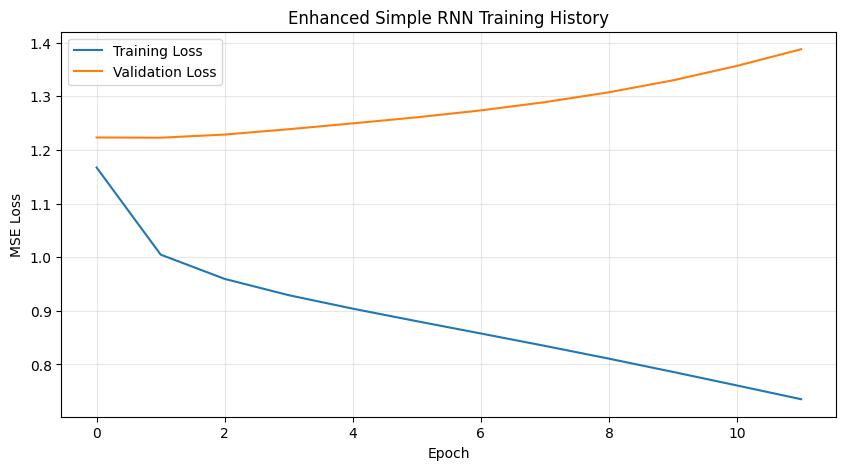

In [130]:
plt.figure(figsize=(10, 5))

plt.plot(
    final_rnn_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    final_rnn_history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Enhanced Simple RNN Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Enhanced RNN Test Evaluation

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The enhanced RNN is evaluated on the final chronological test period.</li>
<li style="margin:4px 0;">Predicted returns are converted back to the original scale and used to reconstruct the next-day closing price.</li>
</ul>
</div>

In [131]:
final_rnn_predictions_scaled = final_rnn_model.predict(
    X_test_final,
    verbose=0
)

final_rnn_predicted_returns = (
    final_target_scaler
    .inverse_transform(final_rnn_predictions_scaled)
    .ravel()
)

final_rnn_actual_returns = (
    final_target_scaler
    .inverse_transform(y_test_final)
    .ravel()
)

In [132]:
final_rnn_price_predictions = (
    test_current_close_final *
    (1 + final_rnn_predicted_returns)
)

In [133]:
final_rnn_mae = mean_absolute_error(
    test_next_close_final,
    final_rnn_price_predictions
)

final_rnn_mse = mean_squared_error(
    test_next_close_final,
    final_rnn_price_predictions
)

final_rnn_rmse = np.sqrt(
    final_rnn_mse
)

print(f"Enhanced RNN MAE: {final_rnn_mae:.4f}")
print(f"Enhanced RNN MSE: {final_rnn_mse:.4f}")
print(f"Enhanced RNN RMSE: {final_rnn_rmse:.4f}")

Enhanced RNN MAE: 4.5940
Enhanced RNN MSE: 41.1814
Enhanced RNN RMSE: 6.4173


In [134]:
final_baseline_predictions = (
    test_current_close_final.copy()
)

final_baseline_mae = mean_absolute_error(
    test_next_close_final,
    final_baseline_predictions
)

final_baseline_mse = mean_squared_error(
    test_next_close_final,
    final_baseline_predictions
)

final_baseline_rmse = np.sqrt(
    final_baseline_mse
)

print(f"Zero-Return Baseline MAE: {final_baseline_mae:.4f}")
print(f"Zero-Return Baseline MSE: {final_baseline_mse:.4f}")
print(f"Zero-Return Baseline RMSE: {final_baseline_rmse:.4f}")

Zero-Return Baseline MAE: 4.4607
Zero-Return Baseline MSE: 40.3660
Zero-Return Baseline RMSE: 6.3534


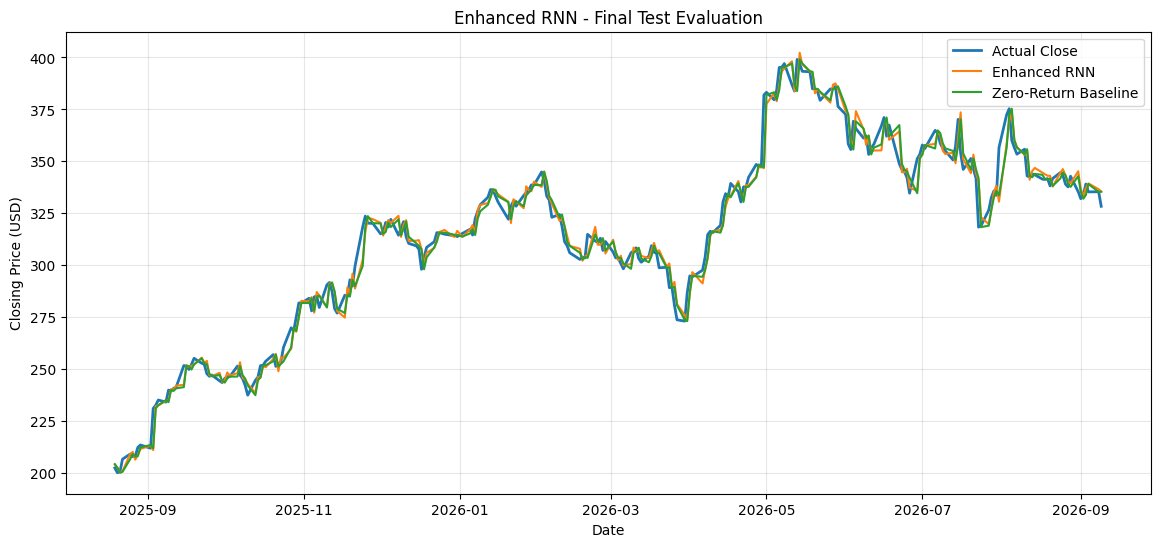

In [135]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates_final,
    test_next_close_final,
    label='Actual Close',
    linewidth=2
)

plt.plot(
    test_dates_final,
    final_rnn_price_predictions,
    label='Enhanced RNN'
)

plt.plot(
    test_dates_final,
    final_baseline_predictions,
    label='Zero-Return Baseline'
)

plt.title('Enhanced RNN - Final Test Evaluation')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Enhanced LSTM

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The LSTM is trained using the same final feature set as the enhanced RNN.</li>
<li style="margin:4px 0;">The target remains the next-day GOOG return.</li>
</ul>
</div>

In [136]:
final_lstm_model = keras.Sequential([
    layers.Input(
        shape=(FINAL_LOOKBACK, FINAL_INPUT_SIZE)
    ),

    layers.LSTM(
        HIDDEN_SIZE
    ),

    layers.Dense(1)
])

final_lstm_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,265 (75.25 KB)

 Trainable params: 19,265 (75.25 KB)

 Non-trainable params: 0 (0.00 B)

In [137]:
final_lstm_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss='mse'
)

In [138]:
final_lstm_early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True
)

In [139]:
final_lstm_history = final_lstm_model.fit(
    X_train_final,
    y_train_final,

    validation_data=(
        X_val_final,
        y_val_final
    ),

    epochs=EPOCHS,
    batch_size=BATCH_SIZE,

    callbacks=[
        final_lstm_early_stopping
    ],

    shuffle=False,
    verbose=1
)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.0028 - val_loss: 1.1450
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9742 - val_loss: 1.1440
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9616 - val_loss: 1.1489
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9512 - val_loss: 1.1541
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9413 - val_loss: 1.1560
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9318 - val_loss: 1.1536
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9228 - val_loss: 1.1559
Epoch 8/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9120 - val_loss: 1.1781
Epoch 9/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9143 - val_loss: 1.1832
Epoch 10/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9034 - val_loss: 1.1728
Epoch 11/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8956 - val_loss: 1.2059
Epoch 12/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8

In [140]:
best_final_lstm_val_loss = min(
    final_lstm_history.history['val_loss']
)

print(
    f"Best Enhanced LSTM Validation Loss: "
    f"{best_final_lstm_val_loss:.6f}"
)

Best Enhanced LSTM Validation Loss: 1.144001


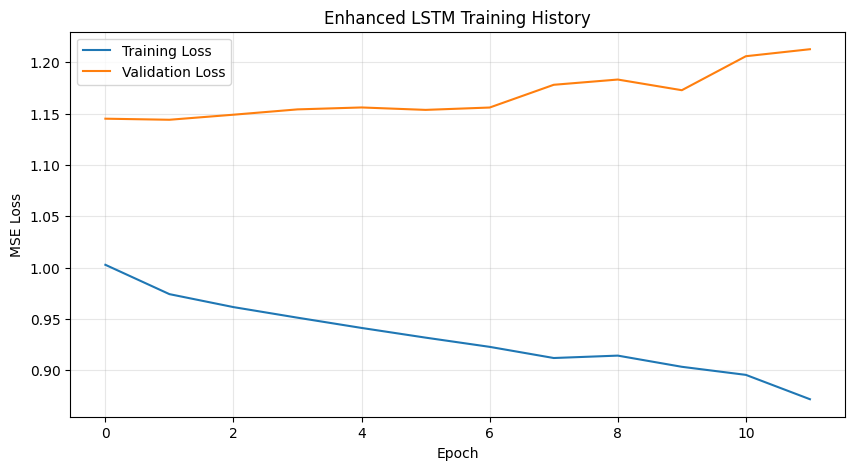

In [141]:
plt.figure(figsize=(10, 5))

plt.plot(
    final_lstm_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    final_lstm_history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Enhanced LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [142]:
final_lstm_predictions_scaled = final_lstm_model.predict(
    X_test_final,
    verbose=0
)

final_lstm_predicted_returns = (
    final_target_scaler
    .inverse_transform(final_lstm_predictions_scaled)
    .ravel()
)

final_lstm_actual_returns = (
    final_target_scaler
    .inverse_transform(y_test_final)
    .ravel()
)

In [143]:
final_lstm_price_predictions = (
    test_current_close_final *
    (1 + final_lstm_predicted_returns)
)

In [144]:
final_lstm_mae = mean_absolute_error(
    test_next_close_final,
    final_lstm_price_predictions
)

final_lstm_mse = mean_squared_error(
    test_next_close_final,
    final_lstm_price_predictions
)

final_lstm_rmse = np.sqrt(
    final_lstm_mse
)

print(f"Enhanced LSTM MAE: {final_lstm_mae:.4f}")
print(f"Enhanced LSTM MSE: {final_lstm_mse:.4f}")
print(f"Enhanced LSTM RMSE: {final_lstm_rmse:.4f}")

Enhanced LSTM MAE: 4.5284
Enhanced LSTM MSE: 40.8942
Enhanced LSTM RMSE: 6.3949


In [145]:
enhanced_comparison = pd.DataFrame({
    'Model': [
        'Zero-Return Baseline',
        'Enhanced RNN',
        'Enhanced LSTM'
    ],

    'MAE': [
        final_baseline_mae,
        final_rnn_mae,
        final_lstm_mae
    ],

    'MSE': [
        final_baseline_mse,
        final_rnn_mse,
        final_lstm_mse
    ],

    'RMSE': [
        final_baseline_rmse,
        final_rnn_rmse,
        final_lstm_rmse
    ]
})

enhanced_comparison.round(4)

,Model,MAE,MSE,RMSE
0,Zero-Return Baseline,4.4607,40.3660,6.3534
1,Enhanced RNN,4.5940,41.1814,6.4173
2,Enhanced LSTM,4.5284,40.8942,6.3949


## Directional Accuracy

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The final models are also evaluated on their ability to predict the direction of the next-day return.</li>
<li style="margin:4px 0;">Directional accuracy is compared with a simple majority-direction baseline.</li>
</ul>
</div>

In [146]:
final_actual_returns = final_lstm_actual_returns

actual_direction = (
    final_actual_returns > 0
)

rnn_direction = (
    final_rnn_predicted_returns > 0
)

lstm_direction = (
    final_lstm_predicted_returns > 0
)

In [147]:
rnn_direction_accuracy = np.mean(
    actual_direction == rnn_direction
)

lstm_direction_accuracy = np.mean(
    actual_direction == lstm_direction
)

print(
    f"Enhanced RNN Directional Accuracy: "
    f"{rnn_direction_accuracy * 100:.2f}%"
)

print(
    f"Enhanced LSTM Directional Accuracy: "
    f"{lstm_direction_accuracy * 100:.2f}%"
)

Enhanced RNN Directional Accuracy: 51.88%
Enhanced LSTM Directional Accuracy: 48.12%


In [148]:
train_direction = (
    final_df
    .iloc[:final_train_end - 1]
    ['Future_Return_1D']
    > 0
)

majority_direction = (
    train_direction.mean() >= 0.5
)

majority_predictions = np.full(
    len(actual_direction),
    majority_direction
)

majority_direction_accuracy = np.mean(
    actual_direction == majority_predictions
)

print(
    f"Majority Baseline Directional Accuracy: "
    f"{majority_direction_accuracy * 100:.2f}%"
)

Majority Baseline Directional Accuracy: 49.62%


In [149]:
direction_comparison = pd.DataFrame({
    'Model': [
        'Majority Baseline',
        'Enhanced RNN',
        'Enhanced LSTM'
    ],

    'Directional Accuracy (%)': [
        majority_direction_accuracy * 100,
        rnn_direction_accuracy * 100,
        lstm_direction_accuracy * 100
    ]
})

direction_comparison.round(2)

,Model,Directional Accuracy (%)
0,Majority Baseline,49.62
1,Enhanced RNN,51.88
2,Enhanced LSTM,48.12


## Directional Confusion Matrix

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">Confusion matrices are used to inspect how well each model distinguishes between upward and downward movements.</li>
<li style="margin:4px 0;">Precision, recall, and F1-score are also reported for both directions.</li>
</ul>
</div>

In [150]:
rnn_conf_matrix = confusion_matrix(
    actual_direction,
    rnn_direction
)

rnn_conf_matrix

array([[60, 74],
       [54, 78]])

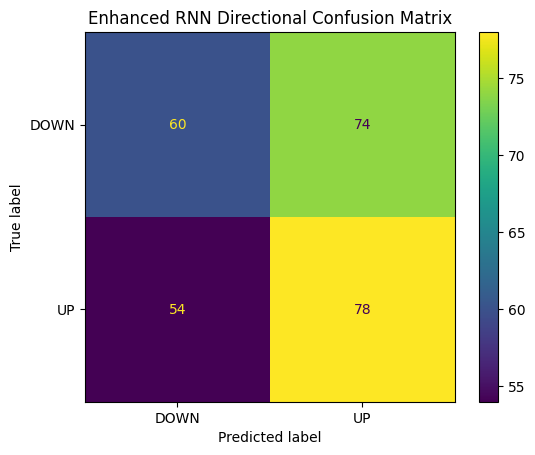

In [151]:
rnn_cm_display = ConfusionMatrixDisplay(
    confusion_matrix=rnn_conf_matrix,
    display_labels=['DOWN', 'UP']
)

rnn_cm_display.plot()

plt.title(
    'Enhanced RNN Directional Confusion Matrix'
)

plt.show()

In [152]:
print(
    classification_report(
        actual_direction,
        rnn_direction,
        target_names=['DOWN', 'UP'],
        digits=4
    )
)

              precision    recall  f1-score   support

        DOWN     0.5263    0.4478    0.4839       134
          UP     0.5132    0.5909    0.5493       132

    accuracy                         0.5188       266
   macro avg     0.5197    0.5193    0.5166       266
weighted avg     0.5198    0.5188    0.5163       266



In [153]:
lstm_conf_matrix = confusion_matrix(
    actual_direction,
    lstm_direction
)

lstm_conf_matrix

array([[48, 86],
       [52, 80]])

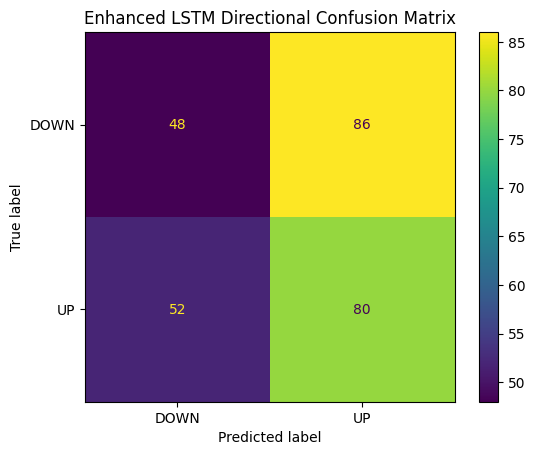

In [154]:
lstm_cm_display = ConfusionMatrixDisplay(
    confusion_matrix=lstm_conf_matrix,
    display_labels=['DOWN', 'UP']
)

lstm_cm_display.plot()

plt.title(
    'Enhanced LSTM Directional Confusion Matrix'
)

plt.show()

In [155]:
print(
    classification_report(
        actual_direction,
        lstm_direction,
        target_names=['DOWN', 'UP'],
        digits=4
    )
)

              precision    recall  f1-score   support

        DOWN     0.4800    0.3582    0.4103       134
          UP     0.4819    0.6061    0.5369       132

    accuracy                         0.4812       266
   macro avg     0.4810    0.4821    0.4736       266
weighted avg     0.4810    0.4812    0.4731       266



## Final Results

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The final enhanced models are compared with the zero-return baseline.</li>
<li style="margin:4px 0;">Price-based errors and directional accuracy are summarized together.</li>
</ul>
</div>

In [156]:
validation_summary = pd.DataFrame({
    'Model': [
        'Enhanced RNN',
        'Enhanced LSTM'
    ],

    'Best Validation Loss': [
        best_final_rnn_val_loss,
        best_final_lstm_val_loss
    ]
})

validation_summary.round(6)

,Model,Best Validation Loss
0,Enhanced RNN,1.222838
1,Enhanced LSTM,1.144001


In [157]:
final_results = pd.DataFrame({
    'Model': [
        'Zero-Return Baseline',
        'Enhanced RNN',
        'Enhanced LSTM'
    ],

    'MAE': [
        final_baseline_mae,
        final_rnn_mae,
        final_lstm_mae
    ],

    'MSE': [
        final_baseline_mse,
        final_rnn_mse,
        final_lstm_mse
    ],

    'RMSE': [
        final_baseline_rmse,
        final_rnn_rmse,
        final_lstm_rmse
    ]
})

final_results.round(4)

,Model,MAE,MSE,RMSE
0,Zero-Return Baseline,4.4607,40.3660,6.3534
1,Enhanced RNN,4.5940,41.1814,6.4173
2,Enhanced LSTM,4.5284,40.8942,6.3949


In [158]:
final_direction_results = pd.DataFrame({
    'Model': [
        'Majority Baseline',
        'Enhanced RNN',
        'Enhanced LSTM'
    ],

    'Directional Accuracy (%)': [
        majority_direction_accuracy * 100,
        rnn_direction_accuracy * 100,
        lstm_direction_accuracy * 100
    ]
})

final_direction_results.round(2)

,Model,Directional Accuracy (%)
0,Majority Baseline,49.62
1,Enhanced RNN,51.88
2,Enhanced LSTM,48.12


## Final Prediction Comparison

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:12px 16px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">
<li style="margin:4px 0;">The final predictions are plotted against the actual GOOG closing prices.</li>
<li style="margin:4px 0;">The zero-return baseline, Enhanced RNN, and Enhanced LSTM are shown together for direct comparison.</li>
</ul>
</div>

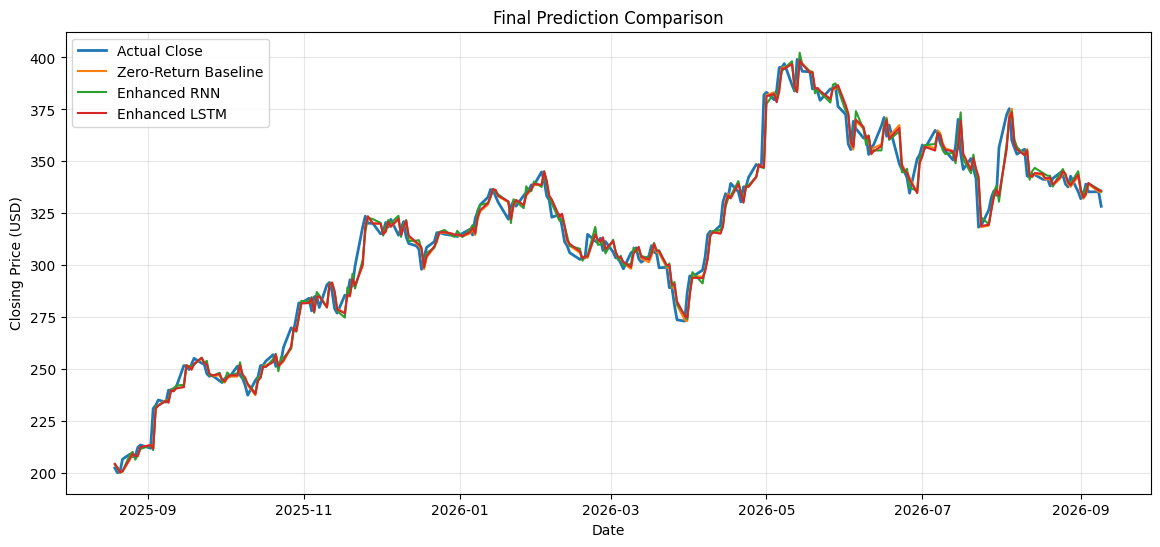

In [159]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates_final,
    test_next_close_final,
    label='Actual Close',
    linewidth=2
)

plt.plot(
    test_dates_final,
    final_baseline_predictions,
    label='Zero-Return Baseline'
)

plt.plot(
    test_dates_final,
    final_rnn_price_predictions,
    label='Enhanced RNN'
)

plt.plot(
    test_dates_final,
    final_lstm_price_predictions,
    label='Enhanced LSTM'
)

plt.title('Final Prediction Comparison')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Conclusion

<div style="background-color:#F2F7F8; border-left:4px solid #236A73; padding:14px 18px; border-radius:6px;">
<ul style="margin:6px 0 2px 20px;">

<li style="margin:7px 0;">
Direct price forecasting with RNN and LSTM followed the broad trend, but both models performed poorly against the simple one-step baseline.
</li>

<li style="margin:7px 0;">
Switching to returns reduced the price-level problem, while SPY, QQQ, and VIX added broader market context to the final models.
</li>

<li style="margin:7px 0;">
On the final test set, the zero-return baseline still achieved the lowest price error. Among the recurrent models, the Enhanced LSTM performed slightly better than the Enhanced RNN.
</li>

<li style="margin:7px 0;">
The Enhanced RNN produced the best directional accuracy at 51.88%, while the Enhanced LSTM reached 48.12%.
</li>

<li style="margin:7px 0;">
Overall, next-day GOOG movement showed only a weak and unstable signal in the features tested here. The results also highlight the importance of simple baselines and chronological evaluation in financial forecasting.
</li>

</ul>
</div>